# Unified CKII Place-Cell Pipeline: First 10 Minutes

This notebook mirrors `Unified_CKII_Pipeline.ipynb`, but derives an isolated first-10-minute data root and compares the first 5 minutes against the second 5 minutes.


In [62]:
%load_ext autoreload
%autoreload 2


force_recompute = True  # Set to True to force recomputation of all results, even if cached results are available

import os
import sys
import json
from pathlib import Path

current_dir = Path(os.getcwd()).resolve()
parent_dir = current_dir.parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

from utils.placecell_pipeline import (
    AnalysisParams,
    PlaceCellParams,
    PFTraversalParams,
    PFDistanceCenteredParams,
    PooledParams,
    CachePolicy,
    PipelineConfig,
    ensure_cache_for_all_animals,
    summarize_statuses,
    summarize_snr_removed_frames,
    summarize_first_last_minute_snr_change,
    plot_animal_movement_summary_boxplots,
    plot_animal_movement_first_last_window_comparison,
    plot_state_dependent_firing_rates_with_plateau_count,
    generate_trial_by_trial_plc_plots,
    generate_distance_defined_trial_by_trial_plc_plots,
    generate_distance_defined_trials_and_dataset,
    build_pf_centered_component_dataset,
    build_pf_distance_centered_component_dataset,
    generate_pf_centered_component_heatmaps,
    generate_pf_distance_centered_component_heatmaps,
    generate_pf_distance_centered_component_heatmaps_2sessions,
    generate_pf_distance_centered_component_heatmaps_2directions,
    plot_pf_centered_category_primary_secondary_from_dataset,
    plot_pf_distance_centered_category_primary_secondary_from_dataset,
    plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions,
    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions,
    compute_pf_distance_centered_pref_nonpref_stats,
    plot_pf_distance_centered_pref_nonpref_stats,
    compute_pf_centered_selectivity_summary,
    plot_pf_centered_selectivity_summary,
    compute_csplus_two_pf_session_delta,
    plot_csplus_two_pf_session_delta,
    compute_csplus_vs_csminus_primary_pf_session_delta,
    plot_csplus_vs_csminus_primary_pf_session_delta,
    compute_pf_distance_centered_session_stability,
    plot_pf_distance_centered_session_stability,
    GLMParams,
    run_pooled_placecell_glm_analysis,
    LNModelParams,
    run_pooled_placecell_ln_model_analysis,
    generate_bin_by_bin_directionality_plots,
    EgocentricTuningParams,
    EgocentricSummaryPlotParams,
    run_pooled_egocentric_tuning_analysis,
    generate_egocentric_valid_spatial_bin_diagnostic_plots,
    generate_egocentric_per_cell_summary_plots,
)

from utils.spatial_heatmaps import (
    classify_spatial_cells,
    compute_global_theta_slow_vlims,
    plot_celltype_distribution_pie,
    plot_selected_cells_figure,
    plot_selected_cells_transposed_figure,
    render_spatial_heatmap_chunks,
)

from utils.pooled_figures_core import (
    prepare_pooled_stats_tables,
    plot_moving_epoch_cs_cb_metrics_allcells_placecells,
    plot_combined_cs_plus_minus_4panels,
    plot_combined_cs_plus_minus_4panels_2sessions,
    plot_combined_cs_plus_minus_session_pair_metrics_14cols,
    plot_cs_plus_plc_correlations_overlay_cs_ss,
    plot_complex_burst_metrics_allbursts_csplus,
    plot_complex_burst_metric_distributions_csplus,
    plot_complex_burst_metric_distributions_quiet_vs_moving_allcells,
    plot_complex_burst_metrics_csplus,
    plot_cbrate_correlations_csplus_inout_alt,
    plot_theta_inout_loco_csplus_vs_csminus,
    plot_slow_vm_inout_loco_csplus_vs_csminus,
)

from utils.session_compare_heatmaps import (
    SessionCompareParams,
    build_session_compare_payloads,
    assemble_session_compare_groups,
    build_session_compare_analysis,
    build_session_split_4panel_tables,
    summarize_session_split_plc_classification,
    render_session_compare_heatmaps,
    plot_session_compare_correlation_stats,
    run_session_compare_heatmaps,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameter Blocks

In [57]:
# Ensure latest pipeline dataclasses are bound in this kernel
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
AnalysisParams = _pcp.AnalysisParams
PlaceCellParams = _pcp.PlaceCellParams
PFTraversalParams = _pcp.PFTraversalParams
PFDistanceCenteredParams = _pcp.PFDistanceCenteredParams
PooledParams = _pcp.PooledParams
CachePolicy = _pcp.CachePolicy
PipelineConfig = _pcp.PipelineConfig
summarize_first_last_minute_snr_change = _pcp.summarize_first_last_minute_snr_change
print(f"Using placecell_pipeline: {_pcp.__file__}")

import utils.session_compare_heatmaps as _sch
importlib.reload(_sch)
SessionCompareParams = _sch.SessionCompareParams
build_session_compare_payloads = _sch.build_session_compare_payloads
assemble_session_compare_groups = _sch.assemble_session_compare_groups
build_session_compare_analysis = _sch.build_session_compare_analysis
build_session_split_4panel_tables = _sch.build_session_split_4panel_tables
summarize_session_split_plc_classification = _sch.summarize_session_split_plc_classification
render_session_compare_heatmaps = _sch.render_session_compare_heatmaps
plot_session_compare_correlation_stats = _sch.plot_session_compare_correlation_stats
run_session_compare_heatmaps = _sch.run_session_compare_heatmaps
print(f"Using session_compare_heatmaps: {_sch.__file__}")

import utils.pooled_figures_core as _pfc
importlib.reload(_pfc)
plot_combined_cs_plus_minus_session_pair_metrics_14cols = _pfc.plot_combined_cs_plus_minus_session_pair_metrics_14cols
print(f"Using pooled_figures_core: {_pfc.__file__}")

# Block 1: Dataset and paths
project_root = parent_dir

source_data_root = project_root / 'data'
data_root = project_root / 'data_first10min'
figures_root = project_root / 'figures'
notebooks_root = project_root / 'notebooks_PCs'

animals = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
    'CKII_pAce50_PRL_20260317',
    'CKII_pAce54_PR_20260506'
]

# First-10-minute derived data helpers
import copy
import pickle
import numpy as np

FIRST_N_MINUTES = 10.0
SESSION_WINDOW_MINUTES = 5.0
FIRST10_FIGURE_FOLDER = 'CKII_pooled_first10min'

EVENT_LIST_KEYS = {
    'spikes',
    'spikes_volpy',
    'all_spikes',
    'refined_SS',
    'all_CS_spikes',
}
PER_CELL_FRAMEWISE_LIST_KEYS = {
    'spike_heights_interpolated',
    'SNR_interpolated',
    'traces_SNR_interpolated',
    'Vm_SNR_interpolated',
}
FRAMEWISE_EVENT_DICT_KEYS = {
    'trace_mf',
    'trace_lp',
    'trace_bl_subtracted',
    'fitted_baseline',
    'trace',
}
EVENT_FRAME_KEYS = {'starts', 'ends', 'locs', 'complex_bursts'}


def _merged_frame_count(merged):
    x = np.asarray(merged.get('x_neural', []))
    if x.ndim == 1 and x.size > 0:
        return int(x.size)
    traces = np.asarray(merged.get('traces', []))
    if traces.ndim == 2:
        return int(max(traces.shape))
    raise ValueError('Could not infer frame count from merged data.')


def _slice_frame_array(value, frame_count, cutoff):
    arr = np.asarray(value)
    if arr.ndim >= 1 and arr.shape[0] == frame_count:
        return arr[:cutoff].copy()
    if arr.ndim >= 2 and arr.shape[1] == frame_count:
        return arr[:, :cutoff].copy()
    return copy.deepcopy(value)


def _filter_frame_indices(value, cutoff):
    arr = np.asarray(value)
    if arr.size == 0:
        return np.asarray(arr, dtype=int)
    try:
        arr_i = np.asarray(arr, dtype=int).reshape(-1)
    except Exception:
        return copy.deepcopy(value)
    arr_i = arr_i[(arr_i >= 0) & (arr_i < int(cutoff))]
    return np.asarray(arr_i, dtype=int)


def _slice_per_cell_framewise_list(value, frame_count, cutoff):
    out = []
    for item in list(value):
        arr = np.asarray(item)
        if arr.ndim == 1 and arr.size == frame_count:
            out.append(arr[:cutoff].copy())
        elif arr.ndim >= 2 and arr.shape[-1] == frame_count:
            slicer = [slice(None)] * arr.ndim
            slicer[-1] = slice(0, cutoff)
            out.append(arr[tuple(slicer)].copy())
        else:
            out.append(copy.deepcopy(item))
    return out


def _event_keep_mask(event_dict, cutoff):
    starts = np.asarray(event_dict.get('starts', []), dtype=int).reshape(-1)
    locs = np.asarray(event_dict.get('locs', event_dict.get('complex_bursts', starts)), dtype=int).reshape(-1)
    ends = np.asarray(event_dict.get('ends', []), dtype=int).reshape(-1)
    n_events = int(max(starts.size, locs.size, ends.size))
    if n_events <= 0:
        return None
    keep = np.ones(n_events, dtype=bool)
    if starts.size == n_events:
        keep &= (starts >= 0) & (starts < int(cutoff))
    if locs.size == n_events:
        keep &= (locs >= 0) & (locs < int(cutoff))
    if ends.size == n_events:
        keep &= (ends >= 0) & (ends < int(cutoff))
    return keep


def _truncate_event_dict(value, frame_count, cutoff):
    if not isinstance(value, dict):
        return copy.deepcopy(value)
    keep = _event_keep_mask(value, cutoff)
    n_events = None if keep is None else int(keep.size)
    out = {}
    for key, item in value.items():
        try:
            arr = np.asarray(item)
        except Exception:
            if keep is not None and isinstance(item, (list, tuple)) and len(item) == n_events:
                out[key] = [copy.deepcopy(v) for v, keep_v in zip(item, keep) if bool(keep_v)]
            else:
                out[key] = copy.deepcopy(item)
            continue
        if key in FRAMEWISE_EVENT_DICT_KEYS or (arr.ndim >= 1 and arr.shape[0] == frame_count):
            out[key] = _slice_frame_array(item, frame_count, cutoff)
        elif keep is not None and arr.ndim >= 1 and arr.shape[0] == n_events:
            out[key] = arr[keep].copy()
        else:
            out[key] = copy.deepcopy(item)
    return out


def _truncate_burst_metric_item(item, cutoff):
    if isinstance(item, dict):
        if 'start' in item:
            try:
                return copy.deepcopy(item) if int(item.get('start', -1)) < int(cutoff) else None
            except Exception:
                return copy.deepcopy(item)
        return {k: _truncate_burst_metric_item(v, cutoff) for k, v in item.items()}
    if isinstance(item, (list, tuple)):
        out = []
        for sub in item:
            kept = _truncate_burst_metric_item(sub, cutoff)
            if kept is not None:
                out.append(kept)
        return out
    return copy.deepcopy(item)


def _truncate_merged_value(key, value, frame_count, cutoff):
    if key in EVENT_LIST_KEYS and isinstance(value, (list, tuple)):
        return [_filter_frame_indices(item, cutoff) for item in value]
    if key in PER_CELL_FRAMEWISE_LIST_KEYS and isinstance(value, (list, tuple)):
        return _slice_per_cell_framewise_list(value, frame_count, cutoff)
    if key in {'complex_bursts_dicts', 'plateaus_dicts'} and isinstance(value, (list, tuple)):
        return [_truncate_event_dict(item, frame_count, cutoff) for item in value]
    if key == 'burst_metrics':
        return _truncate_burst_metric_item(value, cutoff)
    if isinstance(value, np.ndarray):
        return _slice_frame_array(value, frame_count, cutoff)
    return copy.deepcopy(value)


def build_first_n_minute_data_root(source_root, target_root, animals, first_n_minutes=10.0, session_window_minutes=5.0, rebuild=False):
    source_root = Path(source_root)
    target_root = Path(target_root)
    target_root.mkdir(parents=True, exist_ok=True)
    manifest_rows = []

    for animal_id in animals:
        src_dir = source_root / animal_id
        src_path = src_dir / 'merged_aligned_data.pkl'
        if not src_path.exists():
            src_path = src_dir / 'merged_aligned_data_CS.pkl'
        if not src_path.exists():
            raise FileNotFoundError(f'Missing merged data for {animal_id}: {src_dir}')

        dst_dir = target_root / animal_id
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst_path = dst_dir / 'merged_aligned_data.pkl'
        if dst_path.exists() and not rebuild:
            print(f'{animal_id}: first-10 merged data already exists: {dst_path}')
            manifest_rows.append({'animal_id': animal_id, 'path': str(dst_path), 'status': 'reused'})
            continue

        with src_path.open('rb') as f:
            merged = pickle.load(f)
        frame_rate = float(merged.get('frame_rate', np.nan))
        if (not np.isfinite(frame_rate)) or frame_rate <= 0:
            raise ValueError(f'{animal_id}: invalid frame_rate={frame_rate!r}')
        frame_count = _merged_frame_count(merged)
        cutoff = int(np.floor(float(first_n_minutes) * 60.0 * frame_rate))
        cutoff = max(1, min(frame_count, cutoff))
        split_frame = int(np.floor(float(session_window_minutes) * 60.0 * frame_rate))
        split_frame = max(1, min(cutoff, split_frame))

        truncated = {
            key: _truncate_merged_value(key, value, frame_count, cutoff)
            for key, value in merged.items()
            if key != 'session_start_frames'
        }
        truncated['session_start_frames'] = [0, int(split_frame)] if split_frame < cutoff else [0]
        truncated['first10_source_metadata'] = {
            'source_path': str(src_path),
            'source_frame_count': int(frame_count),
            'frame_rate': float(frame_rate),
            'first_n_minutes': float(first_n_minutes),
            'cutoff_frame': int(cutoff),
            'session_window_minutes': float(session_window_minutes),
            'session_split_frame': int(split_frame),
        }

        with dst_path.open('wb') as f:
            pickle.dump(truncated, f, protocol=pickle.HIGHEST_PROTOCOL)

        duration_min = float(cutoff) / frame_rate / 60.0
        manifest_rows.append({
            'animal_id': animal_id,
            'path': str(dst_path),
            'status': 'written',
            'source_frames': int(frame_count),
            'kept_frames': int(cutoff),
            'duration_min': duration_min,
            'session_split_frame': int(split_frame),
        })
        print(
            f'{animal_id}: wrote first-{first_n_minutes:g}min merged data '
            f'({cutoff}/{frame_count} frames, split={split_frame}) -> {dst_path}'
        )
    return manifest_rows


rebuild_first10_data = force_recompute
first10_manifest = build_first_n_minute_data_root(
    source_root=source_data_root,
    target_root=data_root,
    animals=animals,
    first_n_minutes=FIRST_N_MINUTES,
    session_window_minutes=SESSION_WINDOW_MINUTES,
    rebuild=rebuild_first10_data,
)

# Block 2: Core analysis parameters
analysis_params = AnalysisParams(
    speed_threshold=3.,
    speed_threshold_quiet=0.5,
    behavior_speed_outlier_threshold_cm_s=60.0,
    behavior_speed_outlier_cleaning=True,
    min_duration_s=0.25, # minimum duration of a moving epoch (in seconds), default 0.25s
    merge_gap_s=0.0, 
    kernel_size=51,
    snr_threshold=3.5,
    min_good_minutes=5.0, # only include cells with 
    theta_freqs=(4.0, 8.0),
    slow_freqs=2.0,
)

# Block 3: Place cell + traversal parameters
place_cell_params = PlaceCellParams(
    bin_size=1.5, # default 1.5 cm
    place_field_threshold=0.35, # Threshold for place field detection relative to maximum peak rate, default 0.4
    min_component_peak_ratio=0.45, # each PF component peak must be at least this fraction of the map max peak
    split_multi_peak_fields=False, # enable peak-based PF splitting using the criteria below
    split_secondary_peak_ratio=0.6, # split a PF if a secondary local peak is at least this fraction of the primary peak
    split_secondary_peak_min_separation_cm=6.0, # split only if primary and secondary peaks are at least this far apart
    min_peak_rate=0.5, # Minimum peak firing rate (in Hz) for a valid place field, default 0.4
    max_field_area_ratio=0.5, 
    min_field_bins=10, # Minimum number of contiguous bins for a valid place field, default 10
    min_pf_firing_traversals=5, # Minimum number of traversals with spike firing in the PF, default 5
    pf_firing_traversal_distance_window_cm=15.0,
    pf_firing_traversal_detection_window_cm=8.0,
    pf_firing_traversal_distance_bin_cm=1.5,
    pf_firing_traversal_distance_mode='euclidean_to_peak',
    pf_firing_traversal_center_vicinity_min_cm=1,
    pf_firing_traversal_center_vicinity_max_cm=5,
    pf_firing_traversal_resting_speed_threshold=0.5,
    pf_firing_traversal_merge_gap_s=2.0,
    pf_firing_traversal_exclude_trials_with_bad_frames=True,
    pf_reliability_dilation_bins=3, # Dilation size in bins for firing-traversal calculation, default 3 (to prevent small PF being rejected)
    pf_reliability_dilation_shape='disk',
    smooth_sigma=1.5, # for smoothing spatial firing rate maps (in bins), default 2.0
    min_occupancy_s=0.001,
    occ_smooth_sigma=1.5, # for smoothing occupancy maps (in bins), default 2.0
    num_shuffles=1000,
    random_seed=42,
    ss_shape_min_separation_ms=14.0,
    trim_sparse_top_row_for_analysis=True, 
    trim_sparse_top_row_for_plotting=True,
    sparse_top_row_nonocc_frac_threshold=0.8,
)

traversal_params = PFTraversalParams(
    center_by_pf_position=True,
    pf_component_selection='peak_rate',
    min_duration_ms=100.0,
    min_distance_cm=5.0,
    traversal_merge_gap_s=2.0, # merge nearby PF traversals separated by brief rest
    clear_traversal=False,
    session_indices=(0, 1),
    pf_center_window_sec=10.0, # seconds before and after PF entry and exit to include in PF-centered traversal analysis
    min_traversals=10,
    firing_rate_bin_ms=100.0,
    firing_rate_smooth_ms=50.0,
    subtract_pre_traversal_baseline=False, # subtract pre-traversal baseline from theta amp and slow Vm
    mask_non_traversal_pf=True, 
    max_pf_distance_cm=8.0, # maximum allowed distance between a traversal and the PF peak
    plateau_min_duration_ms=100.0,
)

# Block 4: Pooled classification + PSD parameters
pooled_params = PooledParams(
    cb_num_threshold=5, # legacy CS+ criterion: minimum number of complex bursts in PF
    cs_peak_rate_threshold=0.5, # legacy CS+ criterion: CS spatial-map peak firing rate threshold (Hz)
    cs_plc_definition_mode='cs_place_field', # {'legacy', 'cs_place_field'}; cs_place_field uses any CS PF contour
    run_psd_sections=True,
    cs_plc_only=True,
    psd_speed_threshold=3,
    psd_chunk_s=2.0,
    psd_nperseg_s=1.0,
    psd_noverlap_frac=0.5,
    simple_event_window_ms=80.0,
    simple_event_min_gap_ms=50.0,
    min_chunk_valid_fraction=1.0,
    max_freq=100.0,
    normalize_psd=True,
    norm_freq_range=(20.0, 100.0),
)

# Block 5: Figure style
# (Style remains the same because pooled figure generation executes
#  PooledFigure_CKII_Stats_V2.ipynb with patched parameters only.)

# Block 6: Cache policy controls
cache_policy = CachePolicy(
    force_recompute=force_recompute,
    validate_only=False,
    save_executed_notebooks=False,
)

config = PipelineConfig(
    project_root=project_root,
    data_root=data_root,
    figures_root=figures_root,
    notebooks_root=notebooks_root,
    animals=animals,
    analysis=analysis_params,
    place_cell=place_cell_params,
    traversal=traversal_params,
    pooled=pooled_params,
    cache=cache_policy,
)

print('Pipeline Config:')
print(json.dumps({
    'project_root': str(config.project_root),
    'source_data_root': str(source_data_root),
    'data_root': str(config.data_root),
    'first_n_minutes': FIRST_N_MINUTES,
    'session_window_minutes': SESSION_WINDOW_MINUTES,
    'figure_folder': FIRST10_FIGURE_FOLDER,
    'figures_root': str(config.figures_root),
    'notebooks_root': str(config.notebooks_root),
    'animals': config.animals,
    'analysis': config.analysis.__dict__,
    'place_cell': config.place_cell.__dict__,
    'traversal': config.traversal.__dict__,
    'pooled': config.pooled.__dict__,
    'cache': config.cache.__dict__,
}, indent=2))


Using placecell_pipeline: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py
Defined plot_selected_cells_figure() function for session comparison
Using session_compare_heatmaps: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/session_compare_heatmaps.py
Using pooled_figures_core: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/pooled_figures_core.py
CKII_pAce21_PR_20250806: wrote first-10min merged data (299500/299500 frames, split=150000) -> /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data_first10min/CKII_pAce21_PR_20250806/merged_aligned_data.pkl
CKII_pAce38_PX_20251126: wrote first-10min merged data (300000/597670 frames, split=150000) -> /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data_first10min/CKII_pAce38_PX_20251126/merged_aligned_data.pkl
CK

In [13]:
# Ensure/rebuild per-animal cache artifacts
statuses = ensure_cache_for_all_animals(config, force=config.cache.force_recompute)

for st in statuses:
    print(f"[{st.action}] {st.animal_id}")
    if st.reasons:
        print(f"  reasons: {st.reasons}")
    if st.missing_artifacts:
        print(f"  missing: {st.missing_artifacts}")

print('Summary:', summarize_statuses(statuses))


CKII_pAce21_PR_20250806: purged 11 cached artifact files (force_recompute=True).
CKII_pAce21_PR_20250806: behavior speed outlier cleaning threshold=60.0 cm/s, frames=1/299500 (0.000%), max_raw_speed=6431.24 cm/s
CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 19 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 48 bins, peak rate: 9.14 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5611: RuntimeWarning: invalid value encountered in divide
  def _compute_ifr_from_spike_indices(
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5612: RuntimeWarning: invalid value encountered in divide
  n_frames: int,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5694: RuntimeWarning: Mean of empty slice
  mode = str(raw if raw is not None else "").strip().lower()
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5695: RuntimeWarning: Mean of empty slice
  if mode in {"cumulative_path", "cumulative", "path", "path_length", "travel", "traveled_distance"}:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5689: 

Found 26 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 49 bins, peak rate: 6.18 Hz
Found 10 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 14 bins, peak rate: 1.03 Hz
Found 6 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 44 bins, peak rate: 3.26 Hz
CKII_pAce38_PX_20251126: purged 11 cached artifact files (force_recompute=True).
CKII_pAce38_PX_20251126: behavior speed outlier cleaning threshold=60.0 cm/s, frames=42/300000 (0.014%), max_raw_speed=2014.92 cm/s
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 20 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 146 bins, peak rate: 9.88 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5611: RuntimeWarning: invalid value encountered in divide
  def _compute_ifr_from_spike_indices(
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5612: RuntimeWarning: invalid value encountered in divide
  n_frames: int,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5694: RuntimeWarning: Mean of empty slice
  mode = str(raw if raw is not None else "").strip().lower()
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5695: RuntimeWarning: Mean of empty slice
  if mode in {"cumulative_path", "cumulative", "path", "path_length", "travel", "traveled_distance"}:


Found 20 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 46 bins, peak rate: 4.75 Hz
Found 17 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 23 bins, peak rate: 9.83 Hz
Found 22 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 35 bins, peak rate: 2.64 Hz
Found 22 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 64 bins, peak rate: 13.70 Hz
Found 21 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 87 bins, peak rate: 9.20 Hz
Found 29 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 40 bins, peak rate: 1.66 Hz
CKII_pAce45_PX_20260118: purged 11 cached artifact files (force_recompute=True).
CKII_pAce45_PX_20260118: behavior speed outlier cleaning threshold

...

Found 43 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 56 bins, peak rate: 9.49 Hz
Found 20 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 22 bins, peak rate: 5.58 Hz
Found 24 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 90 bins, peak rate: 1.09 Hz
CKII_pAce47_PX_20260128: purged 11 cached artifact files (force_recompute=True).
CKII_pAce47_PX_20260128: behavior speed outlier cleaning threshold=60.0 cm/s, frames=1072/300000 (0.357%), max_raw_speed=14546.24 cm/s
CKII_pAce47_PX_20260128: SNR filter kept 4/5 cells (threshold=3.5, min_good_minutes=5.0).
Found 35 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 40 bins, peak rate: 12.98 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5611: RuntimeWarning: invalid value encountered in divide
  def _compute_ifr_from_spike_indices(
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5612: RuntimeWarning: invalid value encountered in divide
  n_frames: int,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5694: RuntimeWarning: Mean of empty slice
  mode = str(raw if raw is not None else "").strip().lower()
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5695: RuntimeWarning: Mean of empty slice
  if mode in {"cumulative_path", "cumulative", "path", "path_length", "travel", "traveled_distance"}:


Found 29 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 93 bins, peak rate: 7.20 Hz
Found 25 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 31 bins, peak rate: 8.68 Hz
CKII_pAce46_PR_20260222: purged 11 cached artifact files (force_recompute=True).
CKII_pAce46_PR_20260222: behavior speed outlier cleaning threshold=60.0 cm/s, frames=15/300000 (0.005%), max_raw_speed=2376.67 cm/s
CKII_pAce46_PR_20260222: SNR filter kept 5/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 16 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 21 bins, peak rate: 1.59 Hz
CKII_pAce50_PRL_20260317: purged 11 cached artifact files (force_recompute=True).
CKII_pAce50_PRL_20260317: behavior speed outlier cleaning threshold=60.0 cm/s, frames=7/300000 (0.002%), max_raw_speed=470.30 cm/s
CKII_pAce50_PRL_20260317: SNR filter kept 7/9 cells (thres

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5611: RuntimeWarning: invalid value encountered in divide
  def _compute_ifr_from_spike_indices(
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5612: RuntimeWarning: invalid value encountered in divide
  n_frames: int,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5694: RuntimeWarning: Mean of empty slice
  mode = str(raw if raw is not None else "").strip().lower()
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:5695: RuntimeWarning: Mean of empty slice
  if mode in {"cumulative_path", "cumulative", "path", "path_length", "travel", "traveled_distance"}:


Found 8 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 20 bins, peak rate: 4.22 Hz
[recomputed] CKII_pAce21_PR_20250806
  reasons: ['missing_artifacts', 'fingerprint_mismatch', 'force_recompute']
  missing: ['animal_movement_summary', 'burst_metrics_pf', 'pf_centered_trial_data', 'pooled_stats', 'psd_burst_type_state', 'spatial_analysis', 'spike_burst_rates_pf', 'spike_shapes_pf', 'theta_amp_state']
[recomputed] CKII_pAce38_PX_20251126
  reasons: ['missing_artifacts', 'fingerprint_mismatch', 'force_recompute']
  missing: ['animal_movement_summary', 'burst_metrics_pf', 'pf_centered_trial_data', 'pooled_stats', 'psd_burst_type_state', 'spatial_analysis', 'spike_burst_rates_pf', 'spike_shapes_pf', 'theta_amp_state']
[recomputed] CKII_pAce45_PX_20260118
  reasons: ['missing_artifacts', 'fingerprint_mismatch', 'force_recompute']
  missing: ['animal_movement_summary', 'burst_metrics_pf', 'pf_centered_trial_data', 'pooled_stats', 'psd_

## Pooled Figures (Run Individually)

### SNR Frame-Removal Distribution

SNR removed-frame summary (all cells): n_cells=73, removed(<5.0 min good)=20, mean_total=30.01%, median_total=0.72%, source_bad=0.77%, snr_only=29.24%
SNR removed-frame figure saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SNR_RemovedFrameDistribution_all_cells.svg


,scope,n_cells,n_kept_cells,n_removed_min_good_minutes,n_frames_total_cellwise,n_removed_frames_total,n_removed_frames_snr_only,n_removed_frames_source_trace_bad,n_removed_frames_pos_nan,pct_removed_total_cellwise,...,mean_pct_removed_source_trace_bad,median_pct_removed_source_trace_bad,std_pct_removed_source_trace_bad,min_pct_removed_source_trace_bad,max_pct_removed_source_trace_bad,mean_pct_removed_pos_nan,median_pct_removed_pos_nan,std_pct_removed_pos_nan,min_pct_removed_pos_nan,max_pct_removed_pos_nan
0,all_cells_including_removed,73,53,20,21895500,6571739,6402606,169133,558,30.014108,...,0.772941,0.374667,0.905503,0.033667,3.135559,0.002548,0.0,0.006795,0.0,0.020667


,animal_id,n_cells,n_kept_cells,n_removed_min_good_minutes,n_frames_total_cellwise,n_removed_frames_total,n_removed_frames_snr_only,n_removed_frames_source_trace_bad,n_removed_frames_pos_nan,pct_removed_total_cellwise,...,mean_pct_removed_source_trace_bad,median_pct_removed_source_trace_bad,std_pct_removed_source_trace_bad,min_pct_removed_source_trace_bad,max_pct_removed_source_trace_bad,mean_pct_removed_pos_nan,median_pct_removed_pos_nan,std_pct_removed_pos_nan,min_pct_removed_pos_nan,max_pct_removed_pos_nan
0,CKII_pAce21_PR_20250806,9.0,9.0,0.0,2695500.0,84519.0,0.0,84519.0,0.0,3.135559,...,3.135559,3.135559,0.0,3.135559,3.135559,0.000000,0.000000,0.0,0.000000,0.000000
1,CKII_pAce38_PX_20251126,9.0,8.0,1.0,2700000.0,307904.0,299012.0,8892.0,558.0,11.403852,...,0.329333,0.329333,0.0,0.329333,0.329333,0.020667,0.020667,0.0,0.020667,0.020667
2,CKII_pAce45_PX_20260118,16.0,12.0,4.0,4800000.0,1368489.0,1350505.0,17984.0,0.0,28.510188,...,0.374667,0.374667,0.0,0.374667,0.374667,0.000000,0.000000,0.0,0.000000,0.000000
3,CKII_pAce46_PR_20260222,9.0,5.0,4.0,2700000.0,1395589.0,1381063.0,14526.0,0.0,51.688481,...,0.538000,0.538000,0.0,0.538000,0.538000,0.000000,0.000000,0.0,0.000000,0.000000
4,CKII_pAce47_PX_20260128,5.0,4.0,1.0,1500000.0,316227.0,315722.0,505.0,0.0,21.081800,...,0.033667,0.033667,0.0,0.033667,0.033667,0.000000,0.000000,0.0,0.000000,0.000000
5,CKII_pAce50_PRL_20260317,9.0,7.0,2.0,2700000.0,606237.0,598218.0,8019.0,0.0,22.453222,...,0.297000,0.297000,0.0,0.297000,0.297000,0.000000,0.000000,0.0,0.000000,0.000000
6,CKII_pAce54_PR_20260506,16.0,8.0,8.0,4800000.0,2492774.0,2458086.0,34688.0,0.0,51.932792,...,0.722667,0.722667,0.0,0.722667,0.722667,0.000000,0.000000,0.0,0.000000,0.000000


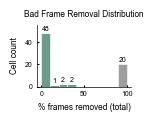

In [58]:
snr_dist_scope_place_cells_only = False

snr_dist = summarize_snr_removed_frames(
    config=config,
    by_place_cells_only=snr_dist_scope_place_cells_only,
    show_plot=True,
    bins=10,
)

snr_dist_figure_name = (
    "SNR_RemovedFrameDistribution_place_cells_only.svg"
    if snr_dist_scope_place_cells_only
    else "SNR_RemovedFrameDistribution_all_cells.svg"
)
_snr_dist_figure_folder = globals().get('figure_save_folder')
if _snr_dist_figure_folder is None:
    _snr_dist_figure_folder = Path(config.figures_root) / globals().get('FIRST10_FIGURE_FOLDER', 'CKII_pooled')
snr_dist_figure_path = Path(_snr_dist_figure_folder) / snr_dist_figure_name
snr_dist_figure = snr_dist.get("figure")
if snr_dist_figure is not None:
    snr_dist_figure_path.parent.mkdir(parents=True, exist_ok=True)
    snr_dist_figure.savefig(snr_dist_figure_path, dpi=300)
    snr_dist["figure_path"] = str(snr_dist_figure_path)
    print(f"SNR removed-frame figure saved: {snr_dist_figure_path}")
else:
    snr_dist["figure_path"] = None
    print("SNR removed-frame figure was not generated.")

display(snr_dist["overall"])
display(snr_dist["per_animal"])


Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 8 cells from CKII_pAce38_PX_20251126
Loaded 12 cells from CKII_pAce45_PX_20260118
Loaded 4 cells from CKII_pAce47_PX_20260128
Loaded 5 cells from CKII_pAce46_PR_20260222
Loaded 7 cells from CKII_pAce50_PRL_20260317
Loaded 8 cells from CKII_pAce54_PR_20260506

Total: 53 cells loaded


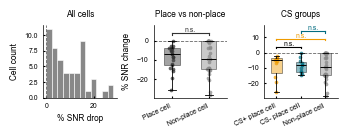

First-vs-last fitted SNR change: valid cells=53/53, median change=-8.28% (negative means SNR dropped).
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SNR_FirstLast1min_SignedChange.svg


,n_cells_total,n_cells_valid_change,n_cells_skipped,first_1min_mean_snr_mean,first_1min_mean_snr_median,first_1min_mean_snr_std,first_1min_mean_snr_sem,first_1min_mean_snr_min,first_1min_mean_snr_max,last_1min_mean_snr_mean,...,last_1min_mean_snr_std,last_1min_mean_snr_sem,last_1min_mean_snr_min,last_1min_mean_snr_max,pct_snr_change_last_vs_first_mean,pct_snr_change_last_vs_first_median,pct_snr_change_last_vs_first_std,pct_snr_change_last_vs_first_sem,pct_snr_change_last_vs_first_min,pct_snr_change_last_vs_first_max
0,53,53,20,4.860005,4.646536,0.944954,0.129799,3.57237,6.863205,4.391264,...,0.802237,0.110196,3.305654,6.20258,-9.133532,-8.283485,7.56441,1.039052,-28.239265,-2.968052e-12


,grouping,group,n_cells,n_animals,first_1min_mean_snr_mean,first_1min_mean_snr_median,first_1min_mean_snr_std,first_1min_mean_snr_sem,first_1min_mean_snr_min,first_1min_mean_snr_max,...,last_1min_mean_snr_std,last_1min_mean_snr_sem,last_1min_mean_snr_min,last_1min_mean_snr_max,pct_snr_change_last_vs_first_mean,pct_snr_change_last_vs_first_median,pct_snr_change_last_vs_first_std,pct_snr_change_last_vs_first_sem,pct_snr_change_last_vs_first_min,pct_snr_change_last_vs_first_max
0,all_cells,All cells,53,7,4.860005,4.646536,0.944954,0.129799,3.572370,6.863205,...,0.802237,0.110196,3.305654,6.202580,-9.133532,-8.283485,7.564410,1.039052,-28.239265,-2.968052e-12
1,place_nonplace,Place cell,21,6,4.920282,4.649146,1.019853,0.222550,3.791037,6.863205,...,0.944851,0.206183,3.305654,6.202580,-8.952171,-6.838416,6.417488,1.400411,-25.720759,-1.797834e-08
2,place_nonplace,Non-place cell,32,7,4.820448,4.576661,0.907041,0.160344,3.572370,6.857237,...,0.704434,0.124527,3.455228,6.164985,-9.252551,-9.428222,8.329173,1.472404,-28.239265,-2.968052e-12
3,cs_place_nonplace,CS+ place cell,10,5,5.283099,5.031863,1.056596,0.334125,3.822905,6.863205,...,1.061032,0.335528,3.561479,6.202580,-9.221028,-5.032089,8.152521,2.578053,-25.720759,-2.566985e+00
4,cs_place_nonplace,CS- place cell,11,5,4.590448,4.244395,0.907821,0.273718,3.791037,6.218948,...,0.755293,0.227729,3.305654,5.342217,-8.707756,-8.361825,4.734246,1.427429,-14.877617,-1.797834e-08
5,cs_place_nonplace,Non-place cell,32,7,4.820448,4.576661,0.907041,0.160344,3.572370,6.857237,...,0.704434,0.124527,3.455228,6.164985,-9.252551,-9.428222,8.329173,1.472404,-28.239265,-2.968052e-12


,comparison,group_a,group_b,n_a,n_b,median_a,median_b,median_delta_a_minus_b,test,statistic,p_value,holm_p_value,significance,holm_significance
0,place_vs_nonplace,Place cell,Non-place cell,21,32,-6.838416,-9.428222,2.589807,mann-whitney u,327.0,0.877160,1.0,n.s.,n.s.
1,csplus_vs_csminus,CS+ place cell,CS- place cell,10,11,-5.032089,-8.361825,3.329736,mann-whitney u,62.0,0.647156,1.0,n.s.,n.s.
2,csplus_vs_nonplace,CS+ place cell,Non-place cell,10,32,-5.032089,-9.428222,4.396133,mann-whitney u,149.0,0.756502,1.0,n.s.,n.s.
3,csminus_vs_nonplace,CS- place cell,Non-place cell,11,32,-8.361825,-9.428222,1.066397,mann-whitney u,178.0,0.966696,1.0,n.s.,n.s.


Skipped/malformed cells:


,animal_id,cell_idx,cell_num,reason
0,CKII_pAce38_PX_20251126,7,8,not in spatial classification output; excluded...
1,CKII_pAce45_PX_20260118,3,4,not in spatial classification output; excluded...
2,CKII_pAce45_PX_20260118,9,10,not in spatial classification output; excluded...
3,CKII_pAce45_PX_20260118,10,11,not in spatial classification output; excluded...
4,CKII_pAce45_PX_20260118,15,16,not in spatial classification output; excluded...
5,CKII_pAce47_PX_20260128,1,2,not in spatial classification output; excluded...
6,CKII_pAce46_PR_20260222,1,2,not in spatial classification output; excluded...
7,CKII_pAce46_PR_20260222,2,3,not in spatial classification output; excluded...
8,CKII_pAce46_PR_20260222,3,4,not in spatial classification output; excluded...
9,CKII_pAce46_PR_20260222,8,9,not in spatial classification output; excluded...


Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SNR_FirstLast1min_SignedChange.svg


In [15]:
snr_change_window_seconds = 60.0

figure_save_folder = os.path.join(str(config.figures_root), FIRST10_FIGURE_FOLDER)
os.makedirs(figure_save_folder, exist_ok=True)

_spatial_data_config_key_current = (
    os.path.abspath(str(config.data_root)),
    tuple(config.animals),
    int(config.pooled.cb_num_threshold),
    float(config.pooled.cs_peak_rate_threshold),
    str(config.pooled.cs_plc_definition_mode),
    float(config.analysis.snr_threshold),
)

if globals().get('spatial_data_config_key') != _spatial_data_config_key_current:
    spatial_data = classify_spatial_cells(
        data_folder=str(config.data_root),
        folders=config.animals,
        cb_num_threshold=config.pooled.cb_num_threshold,
        cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
        cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
        snr_threshold=config.analysis.snr_threshold,
    )
    spatial_data_config_key = _spatial_data_config_key_current
else:
    print('Reusing existing spatial_data for SNR-change grouping.')

snr_first_last = summarize_first_last_minute_snr_change(
    config=config,
    spatial_data=spatial_data,
    window_seconds=snr_change_window_seconds,
    figure_save_folder=figure_save_folder,
    save_name='SNR_FirstLast1min_SignedChange.svg',
    show_plot=True,
)

display(snr_first_last['overall'])
display(snr_first_last['group_summary'])
display(snr_first_last['comparisons'])

if len(snr_first_last['skipped_cells']) > 0:
    print('Skipped/malformed cells:')
    display(snr_first_last['skipped_cells'])

if snr_first_last['figure_path']:
    print(f"Generated: {snr_first_last['figure_path']}")


### Spatial Heatmap Prep (Direct Core Functions)

In [16]:
figure_save_folder = os.path.join(str(config.figures_root), FIRST10_FIGURE_FOLDER)
os.makedirs(figure_save_folder, exist_ok=True)

_spatial_data_config_key_current = (
    os.path.abspath(str(config.data_root)),
    tuple(config.animals),
    int(config.pooled.cb_num_threshold),
    float(config.pooled.cs_peak_rate_threshold),
    str(config.pooled.cs_plc_definition_mode),
    float(config.analysis.snr_threshold),
)

if globals().get('spatial_data_config_key') != _spatial_data_config_key_current:
    spatial_data = classify_spatial_cells(
        data_folder=str(config.data_root),
        folders=config.animals,
        cb_num_threshold=config.pooled.cb_num_threshold,
        cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
        cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
        snr_threshold=config.analysis.snr_threshold,
    )
    spatial_data_config_key = _spatial_data_config_key_current
else:
    print('Reusing existing spatial_data for spatial heatmap prep.')

all_cells_for_vlim = spatial_data.plcs_csplus + spatial_data.plcs_csminus + spatial_data.non_plcs
global_theta_vlim, global_slow_vlim = compute_global_theta_slow_vlims(all_cells_for_vlim)

# Keep style/limits consistent with your current pooled notebook
selected_theta_vlim = [0, 0.2] if global_theta_vlim is not None else None
selected_slow_vlim = [-0.15, 0.15] if global_slow_vlim is not None else None

# Plateau heatmap controls for plot_selected_cells_figure
include_plateau_heatmap = True
plateau_state_mode = 'all'  # {'split', 'all', 'moving', 'resting'}
plateau_include_long_cb_as_plateau = False
plateau_cb_min_duration_ms = 200.0
plateau_speed_threshold = 3.0

print(f"CS+ PLCs: {len(spatial_data.plcs_csplus)}")
print(f"CS- PLCs: {len(spatial_data.plcs_csminus)}")
print(f"Non-PLCs: {len(spatial_data.non_plcs)}")
print(f"theta vlim (global): {global_theta_vlim}; using: {selected_theta_vlim}")
print(f"slow vlim (global): {global_slow_vlim}; using: {selected_slow_vlim}")
print(
    "Plateau settings:",
    {
        'include_plateau_heatmap': include_plateau_heatmap,
        'plateau_state_mode': plateau_state_mode,
        'plateau_include_long_cb_as_plateau': plateau_include_long_cb_as_plateau,
        'plateau_cb_min_duration_ms': plateau_cb_min_duration_ms,
        'plateau_speed_threshold': plateau_speed_threshold,
    }
)



Reusing existing spatial_data for spatial heatmap prep.
CS+ PLCs: 10
CS- PLCs: 11
Non-PLCs: 32
theta vlim (global): (np.float64(0.028442994923503395), np.float64(0.2737430518183532)); using: [0, 0.2]
slow vlim (global): (np.float64(-0.2520723328740043), np.float64(0.2520723328740043)); using: [-0.15, 0.15]
Plateau settings: {'include_plateau_heatmap': True, 'plateau_state_mode': 'all', 'plateau_include_long_cb_as_plateau': False, 'plateau_cb_min_duration_ms': 200.0, 'plateau_speed_threshold': 3.0}


### CellType_Distribution_PieChart

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/CellType_Distribution_PieChart.svg


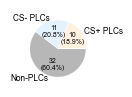

In [17]:
pie_path = os.path.join(figure_save_folder, 'CellType_Distribution_PieChart.svg')

plot_celltype_distribution_pie(
    spatial_data.plcs_csplus,
    spatial_data.plcs_csminus,
    spatial_data.non_plcs,
    save_path=pie_path,
    fig_width=0.8,
    fig_height=1.0,
)

print(f'Saved: {pie_path}')


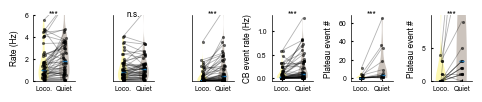

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/StateDep_FiringRates_AllCells_WithPlateauCount.svg
Cells included per subplot:
  1. All: 53
  2. SS: 53
  3. CS: 50
  4. Complex burst rate: 53
  5. Plateau: 17
  6. Plateau zoom: 17
Cells with CB quiet > 10 and CB loco <= 2: 9
Complex burst event counts for those cells: Loco=6, Quiet=273


In [18]:
state_dep_figsize = (4.8, 1.0)
state_dep_rate_ylim_max = 6.0
state_dep_plateau_zoom_ylim_max = 10.0

if "pooled_stats" not in globals():
    pooled_stats = prepare_pooled_stats_tables(
        data_folder=str(config.data_root),
        folders=config.animals,
        cb_num_threshold=config.pooled.cb_num_threshold,
        cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
        cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
        snr_threshold=config.analysis.snr_threshold,
    )

state_dep_out = plot_state_dependent_firing_rates_with_plateau_count(
    config,
    pooled_stats,
    figure_save_folder,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
    rate_ylim_max=state_dep_rate_ylim_max,
    plateau_zoom_ylim_max=state_dep_plateau_zoom_ylim_max,
    figsize=state_dep_figsize,
    save_name="StateDep_FiringRates_AllCells_WithPlateauCount.svg",
    show_plot=True,
)
print(f"Generated: {state_dep_out['figure_path']}")
print("Cells included per subplot:")
print(f"  1. All: {state_dep_out['subplot_counts']['all_rate']}")
print(f"  2. SS: {state_dep_out['subplot_counts']['ss_rate']}")
print(f"  3. CS: {state_dep_out['subplot_counts']['cs_rate']}")
print(f"  4. Complex burst rate: {state_dep_out['subplot_counts']['complex_burst_rate']}")
print(f"  5. Plateau: {state_dep_out['subplot_counts']['plateau']}")
print(f"  6. Plateau zoom: {state_dep_out['subplot_counts']['plateau_zoom']}")
cs_quiet_high_mask = (((state_dep_out['summary_df']['complex_burst_event_count_quiet'] > 10) & (state_dep_out['summary_df']['complex_burst_event_count_loco'] <= 2)).fillna(False))
print(f"Cells with CB quiet > 10 and CB loco <= 2: {int(cs_quiet_high_mask.sum())}")
print(
    "Complex burst event counts for those cells: "
    f"Loco={int(state_dep_out['summary_df'].loc[cs_quiet_high_mask, 'complex_burst_event_count_loco'].fillna(0).sum())}, "
    f"Quiet={int(state_dep_out['summary_df'].loc[cs_quiet_high_mask, 'complex_burst_event_count_quiet'].fillna(0).sum())}"
)


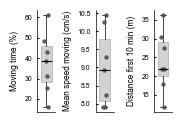

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/AnimalMovementSummary.svg


In [19]:
movement_summary_figsize = (1.8, 1.2)

movement_summary_out = plot_animal_movement_summary_boxplots(
    config,
    figure_save_folder,
    first_n_minutes=10.0,
    figsize=movement_summary_figsize,
    save_name="AnimalMovementSummary.svg",
    show_plot=True,
)
print(f"Generated: {movement_summary_out['figure_path']}")



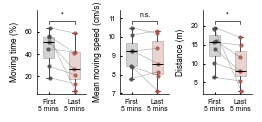

,metric,label,n_animals,first_mean,last_mean,mean_delta_last_minus_first,median_delta_last_minus_first,test,statistic,p_value
0,moving_percent,Moving time (%),7,45.548891,29.888679,-15.660212,-7.344191,wilcoxon,0.0,0.015625
1,mean_speed_cm_s,Mean moving speed (cm/s),7,9.109418,8.817290,-0.292129,-0.308098,wilcoxon,7.0,0.296875
2,distance_m,Distance (m),7,14.375695,9.655042,-4.720653,-2.577426,wilcoxon,0.0,0.015625


Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/AnimalMovementFirstSecond5minComparison.svg


In [20]:
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

movement_first_last_out = _pcp.plot_animal_movement_first_last_window_comparison(
    config,
    figure_save_folder,
    window_minutes=5.0,
    include_short_recordings_in_first_window=True,
    figsize=(2.6, 1.2),
    save_name="AnimalMovementFirstSecond5minComparison.svg",
    show_plot=True,
)

if movement_first_last_out["skipped_animals"]:
    skipped = ", ".join(
        f"{row['animal_id']} ({row['recording_duration_min']:.2f} min)"
        for row in movement_first_last_out["skipped_animals"]
    )
    print(f"Skipped recordings <= 5 min: {skipped}")

if movement_first_last_out["unpaired_animals"]:
    unpaired = ", ".join(
        f"{row['animal_id']} ({row['recording_duration_min']:.2f} min)"
        for row in movement_first_last_out["unpaired_animals"]
    )
    print(f"Included first-5-minute-only recordings: {unpaired}")

display(movement_first_last_out["stats_df"])
print(f"Generated: {movement_first_last_out['figure_path']}")


### SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined

pAce21 Cell 3: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce38 Cell 1: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce38 Cell 4: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce38 Cell 6: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce38 Cell 7: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce45 Cell 5: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce47 Cell 1: removed_snr=101/300000 (0.03%), removed_total=101/300000 (0.03%)
pAce47 Cell 3: removed_snr=101/300000 (0.03%), removed_total=101/300000 (0.03%)
pAce47 Cell 4: removed_snr=101/300000 (0.03%), removed_total=101/300000 (0.03%)
pAce54 Cell 4: removed_snr=2168/300000 (0.72%), removed_total=2168/300000 (0.72%)
pAce21 Cell 1: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce21 Cell 1: CS PF mask is empty
pAce21 Cell 4: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.

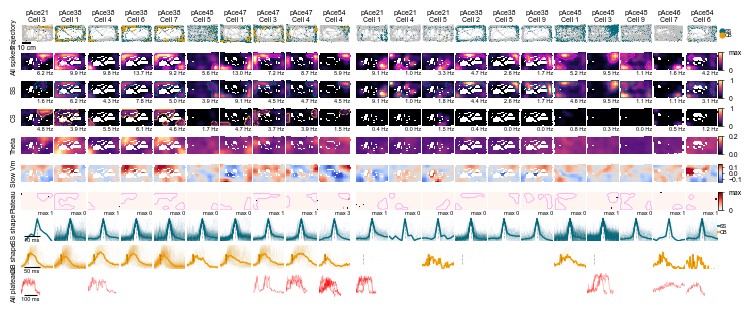

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined.svg


In [21]:
csplus_all = list(spatial_data.plcs_csplus)
csminus_all = list(spatial_data.plcs_csminus)

out_path = os.path.join(figure_save_folder, "SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined.svg")
plot_selected_cells_figure(
    cell_groups=[csplus_all, csminus_all],
    group_names=['CS+ PLC', 'CS- PLC'],
    subplot_width=0.33,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    save_path=out_path,
    plot_putative_PF=True,
    show_place_cell_star=False,
    show_significance_marker=False,
    shape_ylim=(-0.5, 2.0),
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
)
print(f"Generated: {out_path}")



### SpatialHeatmaps_All_NonPLCs (may generate multiple part files)

Rendering SpatialHeatmaps_All_NonPLCs_part01.svg: cells=10
pAce21 Cell 2: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce21 Cell 6: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce21 Cell 7: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce21 Cell 7: SS PF mask is empty
pAce21 Cell 8: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce21 Cell 8: CS PF mask is empty
pAce21 Cell 9: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce38 Cell 3: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce38 Cell 3: CS PF mask is empty
pAce45 Cell 2: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 6: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 7: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 8: removed_snr=1124/300000 (0.37%), removed_total=112

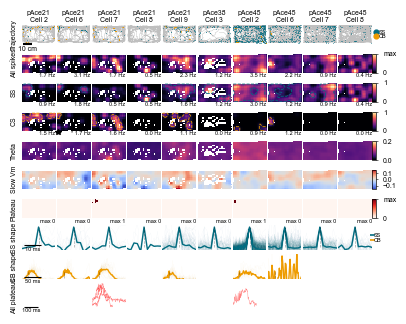

Rendering SpatialHeatmaps_All_NonPLCs_part02.svg: cells=10
pAce45 Cell 12: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 13: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 13: CS PF mask is empty
pAce45 Cell 14: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 14: SS PF mask is empty
pAce45 Cell 15: removed_snr=100948/300000 (33.65%), removed_total=100948/300000 (33.65%)
pAce45 Cell 15: SS PF mask is empty
pAce47 Cell 5: removed_snr=15924/300000 (5.31%), removed_total=15924/300000 (5.31%)
pAce46 Cell 1: removed_snr=1614/300000 (0.54%), removed_total=1614/300000 (0.54%)
pAce46 Cell 5: removed_snr=1614/300000 (0.54%), removed_total=1614/300000 (0.54%)
pAce46 Cell 6: removed_snr=9783/300000 (3.26%), removed_total=9783/300000 (3.26%)
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 8: removed_snr=71178/300000 (23.73%), removed_total=71178/300000 (23.73%)
pAce50 Cell 2: removed_snr=891/300000 (0.30%

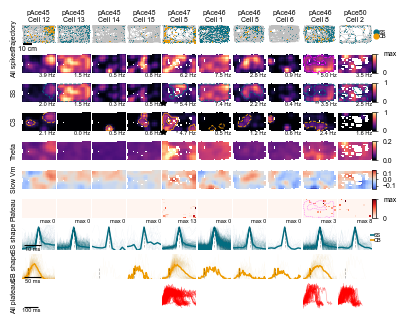

Rendering SpatialHeatmaps_All_NonPLCs_part03.svg: cells=10
pAce50 Cell 4: removed_snr=891/300000 (0.30%), removed_total=891/300000 (0.30%)
pAce50 Cell 4: CS PF mask is empty
pAce50 Cell 5: removed_snr=891/300000 (0.30%), removed_total=891/300000 (0.30%)
pAce50 Cell 5: CS PF mask is empty
pAce50 Cell 6: removed_snr=891/300000 (0.30%), removed_total=891/300000 (0.30%)
pAce50 Cell 6: CS PF mask is empty
pAce50 Cell 7: removed_snr=891/300000 (0.30%), removed_total=891/300000 (0.30%)
pAce50 Cell 7: CS PF mask is empty
pAce50 Cell 8: removed_snr=891/300000 (0.30%), removed_total=891/300000 (0.30%)
pAce50 Cell 9: removed_snr=891/300000 (0.30%), removed_total=891/300000 (0.30%)
pAce54 Cell 1: removed_snr=2168/300000 (0.72%), removed_total=2168/300000 (0.72%)
pAce54 Cell 3: removed_snr=2168/300000 (0.72%), removed_total=2168/300000 (0.72%)
pAce54 Cell 3: CS PF mask is empty
pAce54 Cell 9: removed_snr=2168/300000 (0.72%), removed_total=2168/300000 (0.72%)
pAce54 Cell 12: removed_snr=2168/300000 

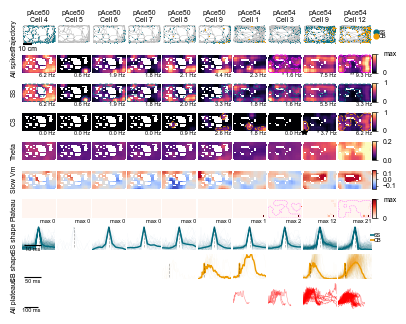

Rendering SpatialHeatmaps_All_NonPLCs_part04.svg: cells=2
pAce54 Cell 13: removed_snr=2168/300000 (0.72%), removed_total=2168/300000 (0.72%)
pAce54 Cell 13: CS PF mask is empty
pAce54 Cell 16: removed_snr=2168/300000 (0.72%), removed_total=2168/300000 (0.72%)
pAce54 Cell 16: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_All_NonPLCs_part04.svg


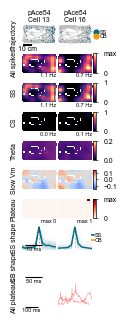

Generated files: 4
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_All_NonPLCs_part01.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_All_NonPLCs_part02.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_All_NonPLCs_part03.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_All_NonPLCs_part04.svg


In [22]:
out_paths = render_spatial_heatmap_chunks(
    spatial_data.non_plcs,
    figure_save_folder=figure_save_folder,
    base_filename='SpatialHeatmaps_All_NonPLCs.svg',
    max_cells_per_figure=10,
    subplot_width=0.35,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    plot_putative_PF=True,
    show_place_cell_star=True,
    show_significance_marker=True,
    pf_only_place_cells=False,
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
)

print(f"Generated files: {len(out_paths)}")
for pth in out_paths:
    print(f"  {pth}")



### SpatilHeatmaps_selected_cells

Selected CS+ cells skipped:
  - pAce45 Cell 12: not in CS+ after first-10 classification
pAce38 Cell 4: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce47 Cell 1: removed_snr=101/300000 (0.03%), removed_total=101/300000 (0.03%)
pAce21 Cell 1: removed_snr=9391/299500 (3.14%), removed_total=9391/299500 (3.14%)
pAce21 Cell 1: CS PF mask is empty
pAce38 Cell 5: removed_snr=926/300000 (0.31%), removed_total=988/300000 (0.33%)
pAce38 Cell 5: CS PF mask is empty
pAce45 Cell 3: removed_snr=1124/300000 (0.37%), removed_total=1124/300000 (0.37%)
pAce45 Cell 3: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_SelectedCells_Transposed_CSplus_CSminus.svg


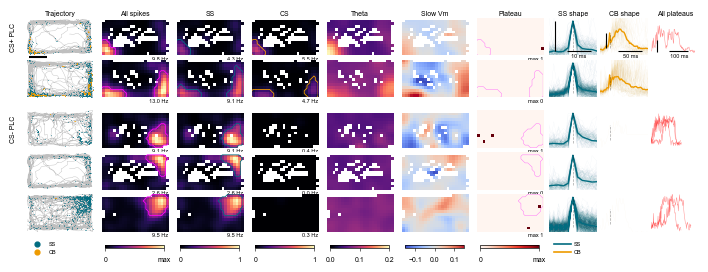

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SpatialHeatmaps_SelectedCells_Transposed_CSplus_CSminus.svg


In [23]:
def _animal_short(cell):
    animal_id = str(cell.get("animal_id", cell.get("session", "")))
    return animal_id.split("_")[1] if "_" in animal_id else animal_id


def _select_spatial_cells(cells, specs, group_label, all_cells=None):
    selected = []
    skipped = []
    all_cells = list(all_cells or [])
    for animal_short, cell_num in specs:
        target_idx = int(cell_num) - 1
        match = [
            cell for cell in cells
            if _animal_short(cell) == animal_short
            and int(cell.get("cell_idx", -1)) == target_idx
        ]
        if match:
            selected.append(match[0])
            continue

        other_match = [
            cell for cell in all_cells
            if _animal_short(cell) == animal_short
            and int(cell.get("cell_idx", -1)) == target_idx
        ]
        if other_match:
            skipped.append(f"{animal_short} Cell {cell_num}: not in {group_label} after first-10 classification")
        else:
            skipped.append(f"{animal_short} Cell {cell_num}: excluded or unavailable after first-10 analysis")

    if skipped:
        print(f"Selected {group_label} cells skipped:")
        for item in skipped:
            print(f"  - {item}")
    return selected


selected_csplus_specs = [
    ("pAce38", 4),
    ("pAce45", 12),
    ("pAce47", 1),
]
selected_csminus_specs = [
    ("pAce21", 1),
    ("pAce38", 5),
    ("pAce45", 3),
]

all_first10_cells = list(spatial_data.valid_spatial_cells)
selected_csplus = _select_spatial_cells(spatial_data.plcs_csplus, selected_csplus_specs, "CS+", all_first10_cells)
selected_csminus = _select_spatial_cells(spatial_data.plcs_csminus, selected_csminus_specs, "CS-", all_first10_cells)

out_path = os.path.join(
    figure_save_folder,
    "SpatialHeatmaps_SelectedCells_Transposed_CSplus_CSminus.svg",
)

if len(selected_csplus) == 0 or len(selected_csminus) == 0:
    print(
        "Skipping selected-cell transposed heatmap because at least one selected group "
        "has no available first-10-minute cells."
    )
else:
    fig = plot_selected_cells_transposed_figure(
        cell_groups=[selected_csplus, selected_csminus],
        group_names=["CS+ PLC", "CS- PLC"],
        subplot_width=0.75,
        figsize=None,
        wspace=0.05,
        hspace=0.15,
        trailing_col_width_ratio=2/3,
        gap_ratio=0.1,
        theta_vlim=selected_theta_vlim,
        slow_vlim=selected_slow_vlim,
        save_path=out_path,
        plot_putative_PF=True,
        show_place_cell_star=False,
        show_significance_marker=False,
        shape_ylim=(-0.5, 2.0),
        include_plateau=include_plateau_heatmap,
        plateau_state_mode=plateau_state_mode,
        plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
        plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
        plateau_speed_threshold=plateau_speed_threshold,
    )
    print(f"Generated: {out_path}")


### Pooled Stats Prep (Direct Core Functions)

In [24]:
pooled_stats = prepare_pooled_stats_tables(
    data_folder=str(config.data_root),
    folders=config.animals,
    cb_num_threshold=config.pooled.cb_num_threshold,
    cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
    cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
    snr_threshold=config.analysis.snr_threshold,
)

df_cs_plc = pooled_stats.df_cs_plc
df_non_cs_plc = pooled_stats.df_non_cs_plc

print(f"Total valid cells: {len(pooled_stats.df_all)}")
print(f"Place cells: {len(pooled_stats.df_pc)}")
print(f"CS+ PLCs: {len(df_cs_plc)}")
print(f"CS- PLCs: {len(df_non_cs_plc)}")


Total valid cells: 53
Place cells: 21
CS+ PLCs: 10
CS- PLCs: 11


### MovingEpoch_CS_CB_Metrics_AllCells_PlaceCells


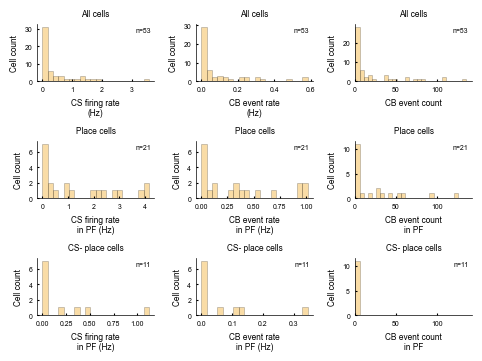

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/MovingEpoch_CS_CB_Metrics_AllCells_PlaceCells.svg


In [25]:
moving_epoch_hist_bins = 20
moving_epoch_count_bin_size = 5
moving_epoch_within_pf = True
out_path = os.path.join(figure_save_folder, 'MovingEpoch_CS_CB_Metrics_AllCells_PlaceCells.svg')
fig = plot_moving_epoch_cs_cb_metrics_allcells_placecells(
    summary_df=state_dep_out['summary_df'],
    classification_df=pooled_stats.df_all,
    save_path=out_path,
    hist_bins=moving_epoch_hist_bins,
    count_bin_size=moving_epoch_count_bin_size,
    within_pf=moving_epoch_within_pf,
    fig_width=4.8,
    fig_height=3.6,
)
plt.show()
print(f'Saved: {out_path}')


### combined_cs_plus_minus_4panels

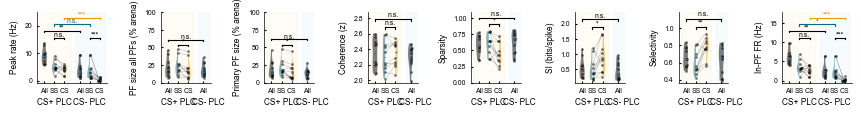

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/combined_cs_plus_minus_4panels.svg


In [26]:
out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_4panels.svg')
fig = plot_combined_cs_plus_minus_4panels(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    plot_cs_minus_ss=False,
    show_only_significant=False,
    fig_width=8.6,
    fig_height=1.2,
)
plt.show()
print(f'Saved: {out_path}')


### cs_plus_plc_correlations_overlay_cs_ss

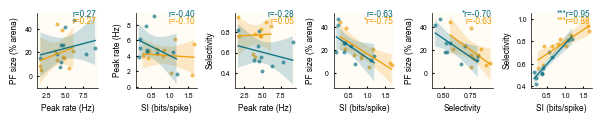

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/cs_plus_plc_correlations_overlay_cs_ss.svg


In [27]:
out_path = os.path.join(figure_save_folder, 'cs_plus_plc_correlations_overlay_cs_ss.svg')
fig = plot_cs_plus_plc_correlations_overlay_cs_ss(
    df_cs_plc=df_cs_plc,
    save_path=out_path,
    overlay_ss_metrics=True,
)
plt.show()
print(f'Saved: {out_path}')


### ComplexBurstMetrics_CSplus_run

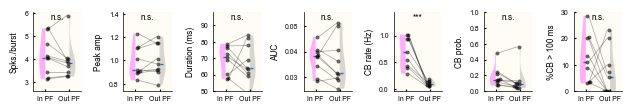

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/ComplexBurstMetrics_CSplus_run.svg


In [28]:
out_path = os.path.join(figure_save_folder, 'ComplexBurstMetrics_CSplus_run.svg')
fig = plot_complex_burst_metrics_csplus(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
    state_key='run',
)
plt.show()
print(f'Saved: {out_path}')


### ComplexBurstMetricDistributions_CSplus_run


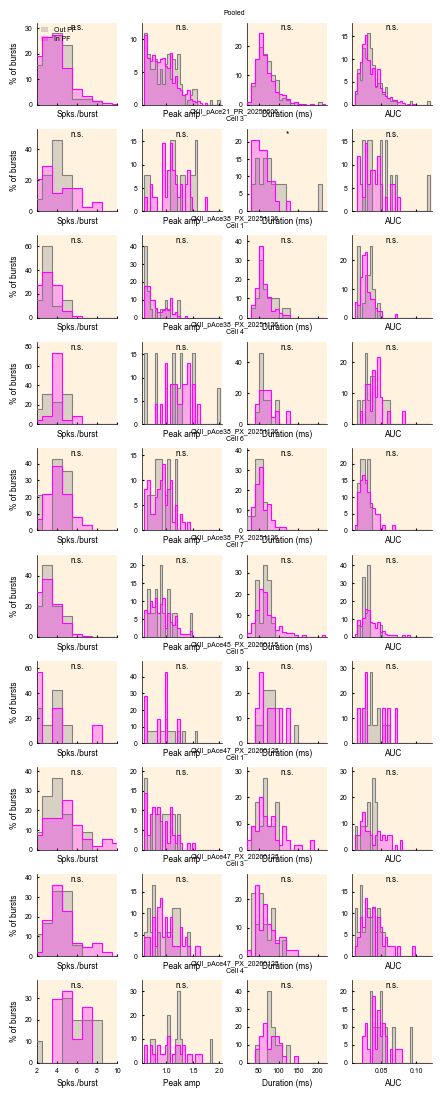

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/ComplexBurstMetricDistributions_CSplus_run.svg


In [29]:
out_path = os.path.join(figure_save_folder, 'ComplexBurstMetricDistributions_CSplus_run.svg')
fig = plot_complex_burst_metric_distributions_csplus(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
    state_key='run',
)
plt.show()
print(f'Saved: {out_path}')


### ComplexBurstMetricDistributions_QuietVsMoving_AllCells


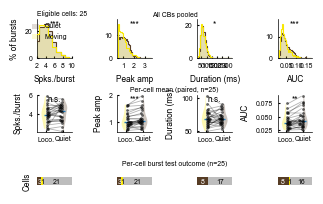

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/ComplexBurstMetricDistributions_QuietVsMoving_AllCells.svg


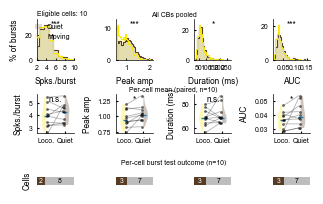

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/ComplexBurstMetricDistributions_QuietVsMoving_CSplusOnly.svg


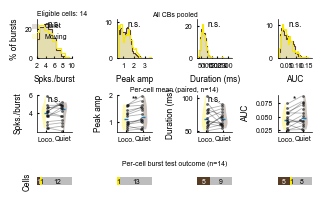

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/ComplexBurstMetricDistributions_QuietVsMoving_NonPLCsOnly.svg


In [30]:
min_bursts_per_state = 5
fig_width = 3.2
fig_height = 2.1

figure_specs = [
    {
        'filename': 'ComplexBurstMetricDistributions_QuietVsMoving_AllCells.svg',
        'plcs_csplus': spatial_data.plcs_csplus,
        'plcs_csminus': spatial_data.plcs_csminus,
        'non_plcs': spatial_data.non_plcs,
    },
    {
        'filename': 'ComplexBurstMetricDistributions_QuietVsMoving_CSplusOnly.svg',
        'plcs_csplus': spatial_data.plcs_csplus,
        'plcs_csminus': [],
        'non_plcs': [],
    },
    {
        'filename': 'ComplexBurstMetricDistributions_QuietVsMoving_NonPLCsOnly.svg',
        'plcs_csplus': [],
        'plcs_csminus': [],
        'non_plcs': spatial_data.non_plcs,
    },
]

for spec in figure_specs:
    out_path = os.path.join(figure_save_folder, spec['filename'])
    fig = plot_complex_burst_metric_distributions_quiet_vs_moving_allcells(
        plcs_csplus=spec['plcs_csplus'],
        plcs_csminus=spec['plcs_csminus'],
        non_plcs=spec['non_plcs'],
        save_path=out_path,
        speed_threshold_cm_s=3.0,
        min_bursts_per_state=min_bursts_per_state,
        plot_mode='hist',
        fig_width=fig_width,
        fig_height=fig_height,
    )
    plt.show()
    print(f'Saved: {out_path}')


### CBrate_correlations_CSplus_InOut_alt

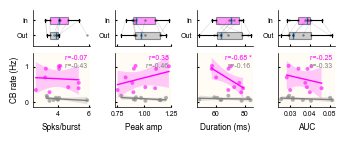

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/CBrate_correlations_CSplus_InOut_alt.svg


In [31]:
out_path = os.path.join(figure_save_folder, 'CBrate_correlations_CSplus_InOut_alt.svg')
fig = plot_cbrate_correlations_csplus_inout_alt(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
)
plt.show()
print(f'Saved: {out_path}')


### theta_inout_loco_csplus_vs_csminus

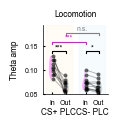

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/theta_inout_loco_csplus_vs_csminus.svg


In [32]:
out_path = os.path.join(figure_save_folder, 'theta_inout_loco_csplus_vs_csminus.svg')
fig = plot_theta_inout_loco_csplus_vs_csminus(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    fig_width=1.2,
    fig_height=1.3,
)
plt.show()
print(f'Saved: {out_path}')


### slow_vm_inout_loco_csplus_vs_csminus

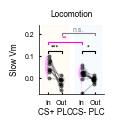

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/slow_vm_inout_loco_csplus_vs_csminus.svg


In [33]:
out_path = os.path.join(figure_save_folder, 'slow_vm_inout_loco_csplus_vs_csminus.svg')
fig = plot_slow_vm_inout_loco_csplus_vs_csminus(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    fig_width=1.2,
    fig_height=1.3,
)
plt.show()
print(f'Saved: {out_path}')


# Trial by Trial Analysis, time based

### Trial-by-Trial Traversal Plots (CS+ PLCs / CS- PLCs, Per PF)

In [ ]:
trial_plot_dilation_bins = 0 #place_cell_params.pf_reliability_dilation_bins  # set 0 for no dilation
trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'
trial_plot_slow_trace_gap = 1.0  # legacy vertical offset: slow Vm below trace
trial_plot_theta_slow_pad_factor = 0.05  # legacy theta-vs-slow padding factor
trial_plot_traversal_merge_gap_s = traversal_params.traversal_merge_gap_s  # gap threshold for merging nearby traversals in trial-by-trial plots (in seconds)

trial_plot_results = generate_trial_by_trial_plc_plots(
    config=config,
    spatial_data=spatial_data,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    save_summary_csv=True,
    show_plots=False,
    show_rest_patches=False, 
    show_pf_prepost_patches=True,
    pf_prepost_patch_alpha=0.05,
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
    trace_slow_gap=trial_plot_slow_trace_gap,
    theta_slow_pad_factor=trial_plot_theta_slow_pad_factor,
    sharey=True,
    traversal_merge_gap_s=trial_plot_traversal_merge_gap_s,
)


print(f"Summary CSV: {trial_plot_results['summary_csv']}")
print(
    f"Dilation used: bins={trial_plot_results['dilation_bins']}, shape={trial_plot_results['dilation_shape']}"
)
print(
    f"Trace/slow/theta offsets: slow_trace_gap={trial_plot_results['trace_slow_gap']}, theta_slow_pad_factor={trial_plot_results['theta_slow_pad_factor']}"
)
print(f"Traversal merge gap (s): {trial_plot_results['traversal_merge_gap_s']}")
print('Counters:')
for k, v in trial_plot_results['counters'].items():
    print(f"  {k}: {v}")

summary_df = trial_plot_results['summary_df']
if len(summary_df) > 0:
    display(summary_df.head(20))

print(f"CS+ output folder: {trial_plot_results['csplus_dir']}")
print(f"CS- output folder: {trial_plot_results['csminus_dir']}")


### PF-Centered Dataset Prep (Primary + Secondary PF)

In [ ]:
pf_centered_dataset = build_pf_centered_component_dataset(
    config=config,
    spatial_data=spatial_data,
    pf_ranks=(1, 2),
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
)

for cat in ('CSplus', 'CSminus'):
    cat_data = pf_centered_dataset.get(cat, {})
    p1 = cat_data.get(1, {})
    p2 = cat_data.get(2, {})
    print(f"{cat} PF1: {p1.get('n_entries', 0)} entries (skipped={p1.get('n_skipped', 0)})")
    print(f"{cat} PF2: {p2.get('n_entries', 0)} entries (skipped={p2.get('n_skipped', 0)})")


### PF-Centered Individual Heatmaps (CS+ / CS-)

In [ ]:
pf_heatmap_summary = generate_pf_centered_component_heatmaps(
    dataset=pf_centered_dataset,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    smooth_window=300,
    fr_vmax_scale=0.6,
    theta_vlim=(0, 0.5),
    slow_vlim=(-0.5, 0.5),
    fig_width=3.8,
    trial_height=0.02,
    xlim=(-4, 4),
    merge_ss_cs=True,
    merge_plateau=True,
    plateau_vlim=0.01,
    avg_smooth_window=0,
    show_plot=False,
)

for cat, info in pf_heatmap_summary.items():
    print(f"{cat} folder: {info['output_dir']}")
    print(f"{cat} summary: {info}")


### PF-Centered Average Plot (CS+; Primary + Secondary)

In [ ]:
out_cs_plus_avg = os.path.join(figure_save_folder, 'pf_centered_CSplus_average_primary_secondary.svg')
pf_avg_fr_row_ylim_max = 1.3  # tune first-row (Norm. FR) ymax
min_traversals_per_type = 5  # minimum number of traversals required per PF type (primary/secondary) to be included in the average plot
plot_pf_centered_category_primary_secondary_from_dataset(
    dataset=pf_centered_dataset,
    category='CSplus',
    title='CS+ PLCs',
    out_path=out_cs_plus_avg,
    smooth_window=400,
    plot_trials=True,
    trial_alpha=0.2,
    trial_linewidth=0.5,
    theta_ylim=(-0.02, 0.1),
    slow_ylim=(-0.05, 0.2),
    fr_ylim_scale=1.2,
    ss_cs_ylim_scale=1.2,
    figsize_per_block=(3.4, 3.0),
    xlim=(-4, 4),
    fr_row_ylim_max=pf_avg_fr_row_ylim_max,
    show_plot=True,
    min_traversals_per_type=min_traversals_per_type,
)
print(f'Generated: {out_cs_plus_avg}')


### PF-Centered Average Plot (CS-; Primary + Secondary)

In [ ]:
out_cs_minus_avg = os.path.join(figure_save_folder, 'pf_centered_CSminus_average_primary_secondary.svg')
pf_avg_fr_row_ylim_max = 1.3  # tune first-row (Norm. FR) ymax
plot_pf_centered_category_primary_secondary_from_dataset(
    dataset=pf_centered_dataset,
    category='CSminus',
    title='CS- PLCs',
    out_path=out_cs_minus_avg,
    smooth_window=400,
    plot_trials=True,
    trial_alpha=0.2,
    trial_linewidth=0.5,
    theta_ylim=(-0.02, 0.1),
    slow_ylim=(-0.05, 0.2),
    fr_ylim_scale=1.2,
    ss_cs_ylim_scale=1.2,
    figsize_per_block=(3.4, 3.0),
    xlim=(-4, 4),
    fr_row_ylim_max=pf_avg_fr_row_ylim_max,
    show_plot=True,
    min_traversals_per_type=min_traversals_per_type,  
)
print(f'Generated: {out_cs_minus_avg}')


### PF-Centered Selectivity Summary (5 Panels)

In [ ]:
selectivity_timepoint_sec = 0.0
selectivity_min_traversals_per_type = 5  # tune this
selectivity_save_csv = True
selectivity_smooth_window = 400  # match PF-centered average plotting smoothing
selectivity_auc_window_sec = (-3.0, 3.0)  # used for theta/slow positive AUC


In [ ]:
pf_selectivity_results = compute_pf_centered_selectivity_summary(
    pf_centered_dataset=pf_centered_dataset,
    timepoint_sec=selectivity_timepoint_sec,
    min_traversals_per_type=selectivity_min_traversals_per_type,
    smooth_window=selectivity_smooth_window,
    auc_window_sec=selectivity_auc_window_sec,
)

print("Skipped counts:", pf_selectivity_results.get("skipped_counts", {}))
print("Example group/metric counts (first 10):")
gmc = pf_selectivity_results.get("group_metric_counts", {})
for k in list(gmc.keys())[:10]:
    print(f"  {k}: {gmc[k]}")


In [ ]:
pf_selectivity_paths = plot_pf_centered_selectivity_summary(
    selectivity_results=pf_selectivity_results,
    figure_save_folder=figure_save_folder,
    show_plot=True,
    save_csv=selectivity_save_csv,
)

print("Generated:")
for k, v in pf_selectivity_paths.items():
    print(f"  {k}: {v}")


### CS+ 2PF Session Delta (SS vs CS)

In [ ]:
csplus_delta_results = compute_csplus_two_pf_session_delta(
    config=config,
    pf_centered_dataset=pf_centered_dataset,
    fr_estimator = "trial_mean", # "pooled" | "trial_mean"
    delta_formula="symmetric",   # 'symmetric' or "fr1"
    force_nonparametric=False,  # auto parametric/nonparametric
    min_total_traversals_per_pf=5,
)

csplus_delta_per_cell = csplus_delta_results['per_cell_pf']
csplus_delta_stats = csplus_delta_results['stats_summary']

print(f"Cells PF1 (eligible): {csplus_delta_results.get('n_cells_pf1', 'n/a')}")
print(f"Cells PF2 (eligible): {csplus_delta_results.get('n_cells_pf2', 'n/a')}")
print(f"Cells overlap PF1&PF2: {csplus_delta_results['n_cells_with_pf1_pf2']}")
print(f"Excluded PF1 entries by traversal gate (<= {csplus_delta_results.get('min_traversals_per_session_per_pf', csplus_delta_results['min_total_traversals_per_pf'])} in any session): {csplus_delta_results.get('n_entries_excluded_low_traversals_pf1', 'n/a')}")
print(f"Excluded PF2 entries by traversal gate (<= {csplus_delta_results.get('min_traversals_per_session_per_pf', csplus_delta_results['min_total_traversals_per_pf'])} in any session): {csplus_delta_results.get('n_entries_excluded_low_traversals_pf2', 'n/a')}")
print(f"Per-cell rows: {len(csplus_delta_per_cell)}")
print(f"Stats rows: {len(csplus_delta_stats)}")

if len(csplus_delta_per_cell) > 0:
    display(csplus_delta_per_cell.head(20))
if len(csplus_delta_stats) > 0:
    display(csplus_delta_stats)


In [ ]:
csplus_delta_fig_paths = plot_csplus_two_pf_session_delta(
    delta_results=csplus_delta_results,
    figure_save_folder=figure_save_folder,
    show_plot=True,
)

print('Generated figures:')
for k, v in csplus_delta_fig_paths.items():
    print(f"  {k}: {v}")


In [ ]:
csplus_delta_per_cell_csv = os.path.join(figure_save_folder, 'csplus_2pf_session_delta_per_cell.csv')
csplus_delta_stats_csv = os.path.join(figure_save_folder, 'csplus_2pf_session_delta_stats.csv')

csplus_delta_per_cell.to_csv(csplus_delta_per_cell_csv, index=False)
csplus_delta_stats.to_csv(csplus_delta_stats_csv, index=False)

print(f"Saved: {csplus_delta_per_cell_csv}")
print(f"Saved: {csplus_delta_stats_csv}")


### CS+ vs CS- Primary PF Session Delta (Primary PF)


In [ ]:
cs_category_delta_results = compute_csplus_vs_csminus_primary_pf_session_delta(
    config=config,
    pf_centered_dataset=pf_centered_dataset,
    fr_estimator="trial_mean",  # "pooled" | "trial_mean"
    delta_formula="symmetric",  # "symmetric" | "fr1"
    force_nonparametric=True,
    min_traversals_per_session_primary_pf=5,
)

cs_category_delta_per_cell = cs_category_delta_results["per_cell_pf"]
cs_category_delta_stats = cs_category_delta_results["stats_summary"]

print(f"CS+ cells: {cs_category_delta_results['n_cells_csplus']}")
print(f"CS- cells: {cs_category_delta_results['n_cells_csminus']}")
print(f"Per-cell rows: {len(cs_category_delta_per_cell)}")
print(f"Stats rows: {len(cs_category_delta_stats)}")
print(f"Excluded by traversal gate CS+: {cs_category_delta_results.get('n_excluded_by_traversal_gate_csplus', 'n/a')}")
print(f"Excluded by traversal gate CS-: {cs_category_delta_results.get('n_excluded_by_traversal_gate_csminus', 'n/a')}")
print(f"Traversal gate threshold (> per session): {cs_category_delta_results.get('min_traversals_per_session_primary_pf', 'n/a')}")

if len(cs_category_delta_per_cell) > 0:
    display(cs_category_delta_per_cell.head(20))
if len(cs_category_delta_stats) > 0:
    display(cs_category_delta_stats)


In [ ]:
cs_category_delta_fig_paths = plot_csplus_vs_csminus_primary_pf_session_delta(
    delta_results=cs_category_delta_results,
    figure_save_folder=figure_save_folder,
    show_plot=True,
)

print("Generated figures:")
for k, v in cs_category_delta_fig_paths.items():
    print(f"  {k}: {v}")


In [ ]:
cs_category_delta_per_cell_csv = os.path.join(figure_save_folder, "csplus_vs_csminus_primary_pf_delta_per_cell.csv")
cs_category_delta_stats_csv = os.path.join(figure_save_folder, "csplus_vs_csminus_primary_pf_delta_stats.csv")

cs_category_delta_per_cell.to_csv(cs_category_delta_per_cell_csv, index=False)
cs_category_delta_stats.to_csv(cs_category_delta_stats_csv, index=False)

print(f"Saved: {cs_category_delta_per_cell_csv}")
print(f"Saved: {cs_category_delta_stats_csv}")


# Session Compare: Heatmaps

### Session-Compare Parameters

In [50]:
session_compare_params = SessionCompareParams(
    panel_mode='s1_s2',  # 's1_s2' or 'combined_s1_s2'
    cache_version='v2',
    rebuild_cache=True,
    max_cells_per_figure=10,
    missing_s2_policy='na_panel',
    occupancy_spearman_threshold=-0.5,
    apply_occupancy_dataset_filter=False,
    enforce_s1s2_min_peak_rate_filter=True,
    s1s2_min_peak_rate_hz=0.5,
    clean_heatmap=True,
    heatmap_similarity_metric='weighted_pearson',
    plot_spike_shapes=True,
    plot_spike_shapes_overall=True,
    plot_spike_shapes_in_field=True,
    plot_spike_shapes_out_field=True,
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
    two_session_split_mode='time_windows',
    two_session_split_window_minutes=5.0,  # first/second 5 min windows
    align_to_distance_normalized_exports=True,
    distance_normalized_export_dir=os.path.join(figure_save_folder, 'pf_distance_centered_2sessions_average_exports'),
    distance_normalized_min_trials_per_session=4,
    distance_normalized_pf_rank=1,
    selected_theta_vlim=None,
    selected_slow_vlim=None,
    quiet_epoch_mode='strict_low_speed',  # 'strict_low_speed' or 'non_moving'
)

print(session_compare_params)


SessionCompareParams(panel_mode='s1_s2', cache_version='v2', rebuild_cache=True, max_cells_per_figure=10, missing_s2_policy='na_panel', occupancy_spearman_threshold=-0.5, apply_occupancy_dataset_filter=False, enforce_s1s2_min_peak_rate_filter=True, s1s2_min_peak_rate_hz=0.5, clean_heatmap=True, heatmap_similarity_metric='weighted_pearson', plot_spike_shapes=True, plot_spike_shapes_overall=True, plot_spike_shapes_in_field=True, plot_spike_shapes_out_field=True, plot_PF_combined=True, include_plateau=True, plateau_state_mode='all', plateau_include_long_cb_as_plateau=False, plateau_cb_min_duration_ms=200.0, plateau_speed_threshold=3.0, two_session_split_mode='time_windows', two_session_split_window_minutes=5.0, align_to_distance_normalized_exports=True, distance_normalized_export_dir='/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_2sessions_average_exports', distance_normalized_min_trials_per_sessi

### Build/Load Payloads + Assemble Groups

In [51]:
session_compare_analysis = build_session_compare_analysis(config, session_compare_params)
session_compare_payloads = session_compare_analysis['payloads']
session_compare_groups = session_compare_analysis['groups']
session_split_4panel_tables = session_compare_analysis['session_split_4panel_tables']
session_split_classification = session_compare_analysis['session_split_classification']

print(f"Datasets loaded: {len(session_compare_payloads['session_payload_by_dataset'])}")
print(f"Allowed datasets after occupancy filter: {len(session_compare_groups['allowed_dataset_ids'])}")
print(f"Excluded datasets: {len(session_compare_groups['excluded_dataset_ids'])}")
print(f"CS+ rows: {len(session_compare_groups['csplus_groups'])}")
print(f"CS- rows: {len(session_compare_groups['csminus_groups'])}")
print(f"Non-PLC rows: {len(session_compare_groups['nonpc_groups'])}")
print(
    "Split 4-panel rows: "
    f"S1 CS+={len(session_split_4panel_tables['session1']['df_cs_plc'])}, "
    f"S1 CS-={len(session_split_4panel_tables['session1']['df_non_cs_plc'])}, "
    f"S2 CS+={len(session_split_4panel_tables['session2']['df_cs_plc'])}, "
    f"S2 CS-={len(session_split_4panel_tables['session2']['df_non_cs_plc'])}"
)
print(f"Theta vlim: {session_compare_groups['selected_theta_vlim']}")
print(f"Slow vlim: {session_compare_groups['selected_slow_vlim']}")

display(session_compare_groups['occupancy_similarity_df'])
display(session_compare_analysis['session_split_classification_summary_df'])
display(session_compare_analysis['nonplc_becomes_plc_df'])


CKII_pAce21_PR_20250806: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=0.0).
CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=0.0).
Saved session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data_first10min/CKII_pAce21_PR_20250806/spatial_session_cache_v2.pkl
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=0.0).
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=0.0).
Saved session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data_first10min/CKII_pAce38_PX_20251126/spatial_session_cache_v2.pkl
CKII_pAce45_PX_20260118: SNR filter kept 12/16 cells (threshold=3.5, min_good_minutes=0.0).
CKII_pAce45_PX_20260118: SNR filter kept 12/16 cells (threshold=3.5, min_good_minutes=0.0).
Saved session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline

,dataset_id,occupancy_spearman,n_valid_bins
0,CKII_pAce21_PR_20250806,0.447695,336
1,CKII_pAce38_PX_20251126,0.800567,336
2,CKII_pAce45_PX_20260118,0.370439,336
3,CKII_pAce47_PX_20260128,0.508823,336
4,CKII_pAce46_PR_20260222,0.437823,336
5,CKII_pAce50_PRL_20260317,-0.122052,336
6,CKII_pAce54_PR_20260506,0.431823,336


,combined_group,n_cells,session1_CS+_PLC,session1_CS-_PLC,session1_Non-PLC,session1_missing,session2_CS+_PLC,session2_CS-_PLC,session2_Non-PLC,session2_missing,same_label_both_sessions,becomes_split_session_PLC
0,combined CS+ PLC,9,7,0,2,0,2,0,7,0,1,0
1,combined CS- PLC,6,0,4,2,0,0,2,4,0,1,0
2,combined Non-PLC,31,0,1,30,0,0,0,31,0,30,1


,combined_group,animal_id,session,cell_idx,session1_label,session2_label,session1_is_place_cell,session2_is_place_cell,session1_n_cb_run_in,session2_n_cb_run_in,session1_cs_peak_rate,session2_cs_peak_rate
20,combined Non-PLC,CKII_pAce45_PX_20260118,CKII_pAce45_PX_20260118,1,CS- PLC,Non-PLC,True,False,5,2,1.430295,1.479084


### Render Session-Compare Heatmaps

Plotting CS+ comparison (n=9, 2 conditions each)
  Rendering CS+ part 1/1: n=9 -> spatial_compare_csplus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/spatial_compare_csplus_s1_s2.svg


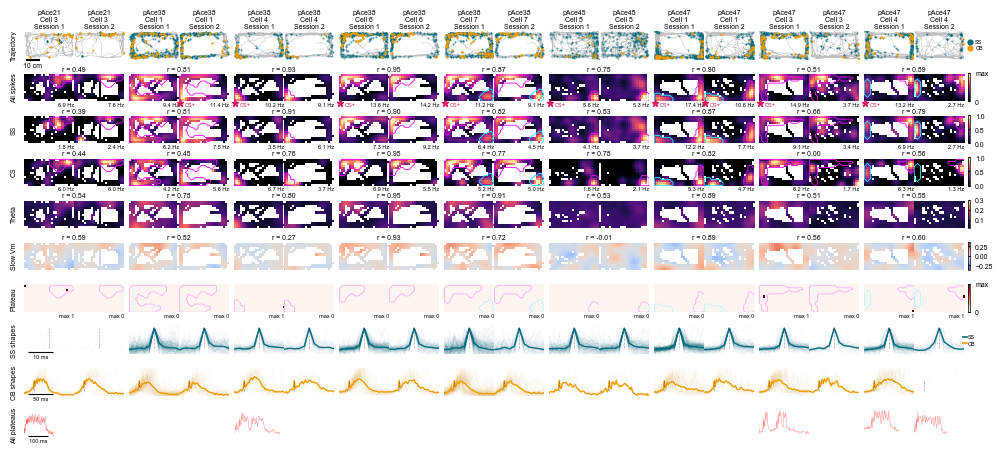

Plotting CS- comparison (n=6, 2 conditions each)
  Rendering CS- part 1/1: n=6 -> spatial_compare_csminus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/spatial_compare_csminus_s1_s2.svg


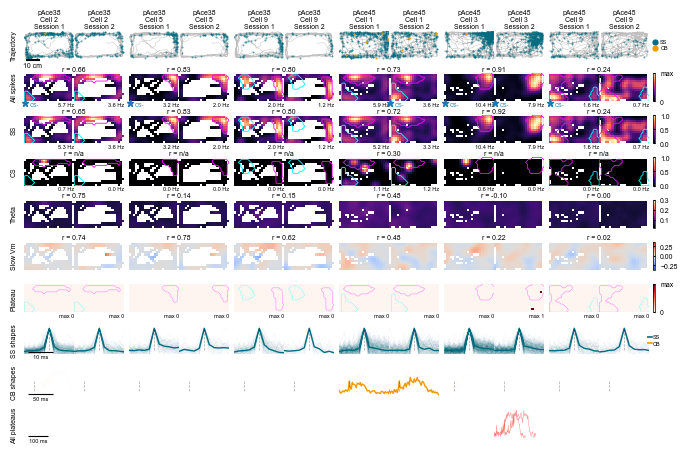

Plotting Non-PLC comparison (n=31, 2 conditions each)
  Rendering Non-PLC part 1/4: n=10 -> spatial_compare_nonplc_s1_s2_part01.svg
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/spatial_compare_nonplc_s1_s2_part01.svg


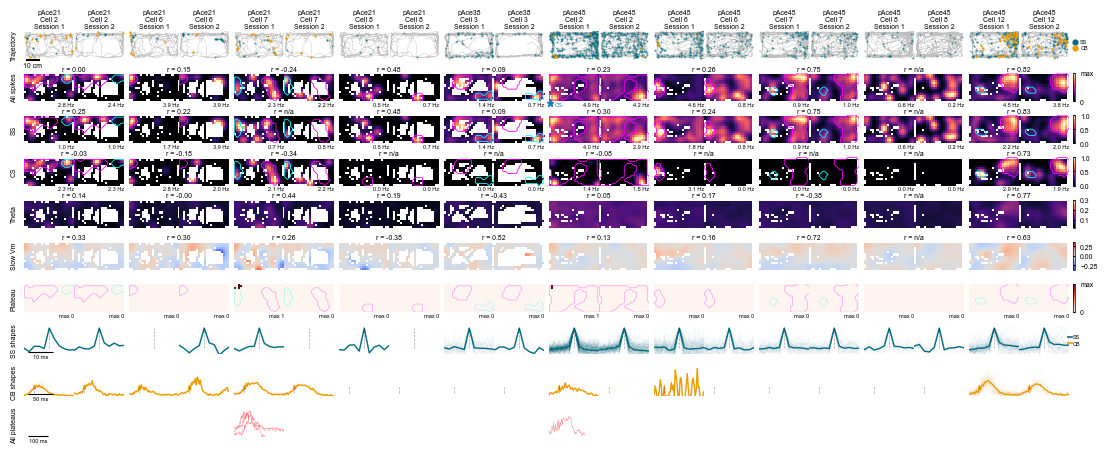

  Rendering Non-PLC part 2/4: n=10 -> spatial_compare_nonplc_s1_s2_part02.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/spatial_compare_nonplc_s1_s2_part02.svg


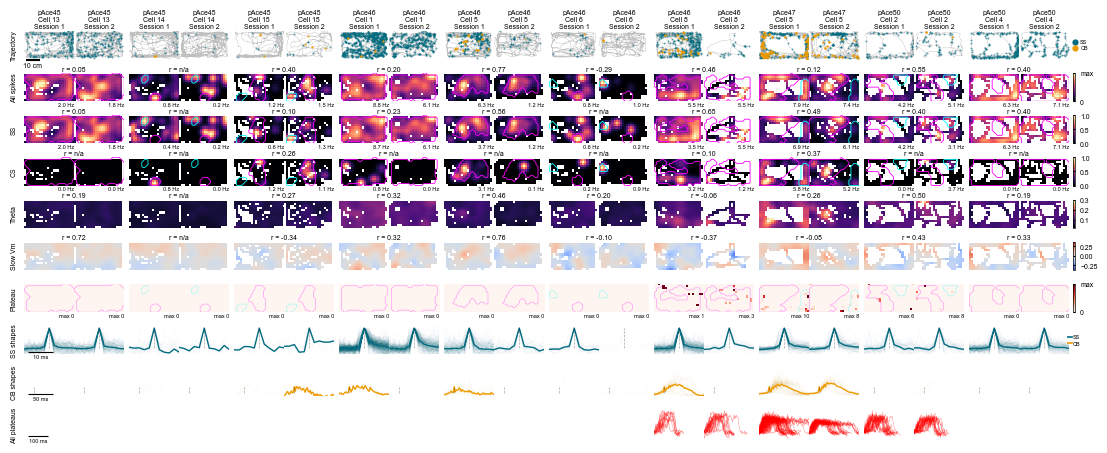

  Rendering Non-PLC part 3/4: n=10 -> spatial_compare_nonplc_s1_s2_part03.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/spatial_compare_nonplc_s1_s2_part03.svg


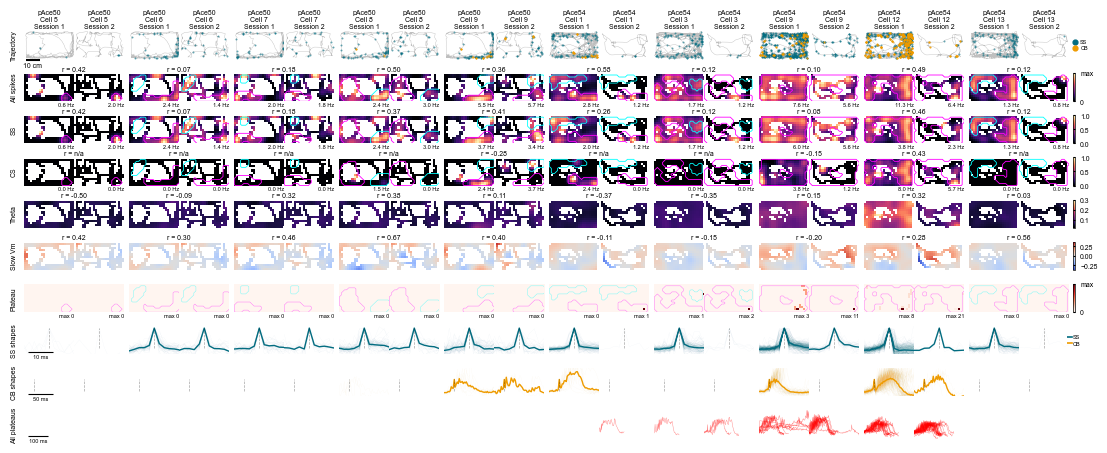

  Rendering Non-PLC part 4/4: n=1 -> spatial_compare_nonplc_s1_s2_part04.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/spatial_compare_nonplc_s1_s2_part04.svg


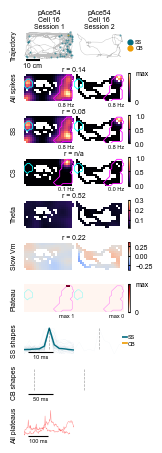

Figure folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min
Panel mode: s1_s2
Saved CS+ figures: 1
Saved CS- figures: 1
Saved Non-PLC figures: 4


In [52]:
session_compare_render = render_session_compare_heatmaps(
    config=config,
    params=session_compare_params,
    groups_payload=session_compare_groups,
    figure_save_folder=figure_save_folder,
)

print(f"Figure folder: {session_compare_render['figure_save_folder']}")
print(f"Panel mode: {session_compare_render['panel_mode']}")
print(f"Saved CS+ figures: {len(session_compare_render['saved_csplus'])}")
print(f"Saved CS- figures: {len(session_compare_render['saved_csminus'])}")
print(f"Saved Non-PLC figures: {len(session_compare_render['saved_nonplc'])}")


## Stats

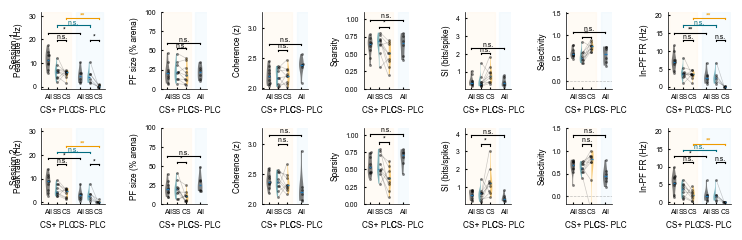

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/combined_cs_plus_minus_4panels_2sessions.svg
Rows plotted: S1 CS+=9, S1 CS-=6, S2 CS+=9, S2 CS-=6


In [53]:
session_split_4panel_out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_4panels_2sessions.svg')
fig = plot_combined_cs_plus_minus_4panels_2sessions(
    session_tables=session_split_4panel_tables,
    save_path=session_split_4panel_out_path,
    plot_cs_minus_ss=False,
    fig_width=7.5,
    fig_height=2.4,
)
plt.show()
print(f'Saved: {session_split_4panel_out_path}')
print(
    "Rows plotted: "
    f"S1 CS+={len(session_split_4panel_tables['session1']['df_cs_plc'])}, "
    f"S1 CS-={len(session_split_4panel_tables['session1']['df_non_cs_plc'])}, "
    f"S2 CS+={len(session_split_4panel_tables['session2']['df_cs_plc'])}, "
    f"S2 CS-={len(session_split_4panel_tables['session2']['df_non_cs_plc'])}"
)


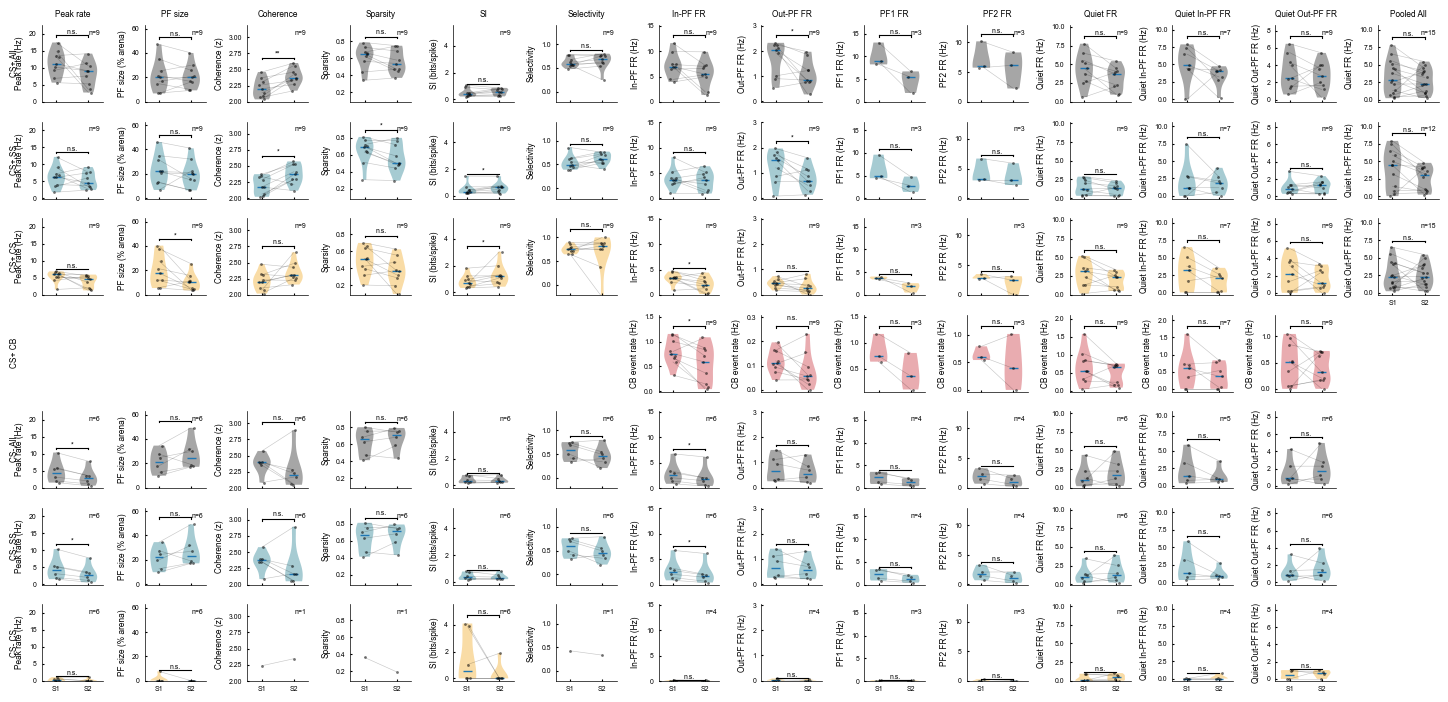

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/combined_cs_plus_minus_session1_vs_session2_metrics_14cols.svg


In [54]:
session_pair_metrics_out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_session1_vs_session2_metrics_14cols.svg')
fig = plot_combined_cs_plus_minus_session_pair_metrics_14cols(
    session_tables=session_split_4panel_tables,
    save_path=session_pair_metrics_out_path,
    fig_width=14.5,
    fig_height=7.0,
)
plt.show()
print(f'Saved: {session_pair_metrics_out_path}')


### S1/S2 Correlation Statistics


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SessionCompare_S1S2_CorrelationStats.svg


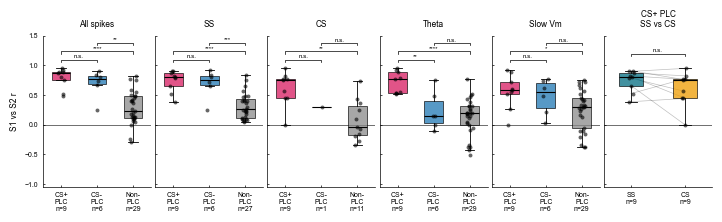

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/SessionCompare_S1S2_CorrelationStats.svg


,metric,metric_label,group,n,mean,sem,sd,median,min,max,similarity_metric,similarity_label
0,all_spike,All spikes,CS+ PLC,9,0.787681,0.057557,0.172671,0.869734,0.492519,0.948433,weighted_pearson,r
1,all_spike,All spikes,CS- PLC,6,0.698618,0.097308,0.238355,0.768689,0.243993,0.913896,weighted_pearson,r
2,all_spike,All spikes,Non-PLC,29,0.285803,0.050963,0.274444,0.225134,-0.294099,0.817293,weighted_pearson,r
3,ss,SS,CS+ PLC,9,0.742215,0.060352,0.181056,0.811183,0.388479,0.910634,weighted_pearson,r
4,ss,SS,CS- PLC,6,0.692899,0.097567,0.238990,0.760274,0.243993,0.916000,weighted_pearson,r
5,ss,SS,Non-PLC,27,0.319198,0.041473,0.215499,0.263591,0.054042,0.830642,weighted_pearson,r
6,cs,CS,CS+ PLC,9,0.614365,0.095927,0.287780,0.757696,0.000575,0.950502,weighted_pearson,r
7,cs,CS,CS- PLC,1,0.295115,NaN,NaN,0.295115,0.295115,0.295115,weighted_pearson,r
8,cs,CS,Non-PLC,11,0.074808,0.100788,0.334277,-0.029143,-0.337930,0.729198,weighted_pearson,r
9,theta,Theta,CS+ PLC,9,0.718015,0.061578,0.184735,0.776398,0.511424,0.952057,weighted_pearson,r


,metric,metric_label,comparison,group1,group2,group1_index,group2_index,test,statistic,p_value,significance,n_group1,n_group2,shapiro_p_group1,shapiro_p_group2,reason,similarity_metric,similarity_label
0,all_spike,All spikes,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Mann-Whitney U,36.000000,0.327672,n.s.,9,6,0.029250,0.094374,,weighted_pearson,r
1,all_spike,All spikes,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Mann-Whitney U,246.000000,0.000079,****,9,29,0.029250,0.435157,,weighted_pearson,r
2,all_spike,All spikes,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Unpaired t-test,3.418077,0.001693,**,6,29,0.094374,0.435157,,weighted_pearson,r
3,ss,SS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,0.455817,0.656042,n.s.,9,6,0.090142,0.150200,,weighted_pearson,r
4,ss,SS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,5.286109,0.000007,****,9,27,0.090142,0.051930,,weighted_pearson,r
5,ss,SS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Unpaired t-test,3.772870,0.000684,***,6,27,0.150200,0.051930,,weighted_pearson,r
6,cs,CS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,n/a,NaN,NaN,n.s.,9,1,NaN,NaN,fewer than three finite values in one or both ...,weighted_pearson,r
7,cs,CS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,3.817442,0.001261,**,9,11,0.187453,0.553850,,weighted_pearson,r
8,cs,CS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,n/a,NaN,NaN,n.s.,1,11,NaN,NaN,fewer than three finite values in one or both ...,weighted_pearson,r
9,theta,Theta,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,3.716589,0.002587,**,9,6,0.051448,0.478114,,weighted_pearson,r


,comparison,group,metric1,metric2,test,statistic,p_value,significance,n_pairs,shapiro_p,shapiro_p_diff,reason,similarity_metric,similarity_label
0,CS+ PLC SS vs CS,CS+ PLC,ss,cs,Paired t-test,1.438479,0.188246,n.s.,9,0.728413,0.728413,,weighted_pearson,r


In [55]:
session_compare_corr_stats = plot_session_compare_correlation_stats(
    session_compare_groups,
    session_compare_params,
    figure_save_folder=figure_save_folder,
    show_plot=True,
    save_csv=True,
)

print(f"Saved: {session_compare_corr_stats['figure_path']}")
display(session_compare_corr_stats['summary_df'])
display(session_compare_corr_stats['pairwise_df'])
display(session_compare_corr_stats['paired_stats_df'])


# Trial by Trial Analysis, Distance normalized

## Trial by trial plots with distance windowing

In [40]:
distance_centered_params = PFDistanceCenteredParams(
    distance_window_cm=15.0,
    detection_window_cm=10.0,
    distance_bin_cm=1.5,
    distance_mode='cumulative_path',
    center_by_pf_position=True,
    min_traversals=10,
    min_traversals_per_type=5,
    require_full_span=False,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=5.0, # cm
    exclude_trials_with_bad_frames=True,
    require_movement=True,
    include_long_cb_as_plateau=True,
    cb_plateau_min_duration_ms=100.0,
)



In [41]:
## Trial by Trial plots + unified distance dataset

distance_defined_distance_window_cm = 15.0 # default 15
distance_defined_detection_window_cm = 8.0
distance_defined_distance_bin_cm = 1.5 # default 1.5
distance_defined_distance_mode = 'euclidean_to_peak'  # alternative: 'euclidean_to_peak'
distance_defined_center_vicinity_min_cm = 1
distance_defined_center_vicinity_max_cm = 5
distance_defined_moving_speed_threshold = float(config.analysis.speed_threshold)
distance_defined_resting_speed_threshold = 0.5
distance_defined_trial_sharey = True
distance_defined_max_plot_trial_duration_s = 20.0

distance_defined_categories = ('CSplus', 'CSminus', 'non-PLC')  # e.g. ('non-PLC',) or ('CSplus','CSminus','non-PLC')

# Related to Plateaus
distance_defined_include_long_cb_as_plateau = False
distance_defined_cb_plateau_min_duration_ms = 100.0
distance_defined_include_resting_plateaus = True
distance_defined_align_all_pf_components_to_session_compare = True
distance_defined_session_compare_cache_version = 'v2'

trial_plot_dilation_bins = 0 #place_cell_params.pf_reliability_dilation_bins  # set 0 for no dilation
trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'

distance_defined_unified_result = generate_distance_defined_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    distance_params=distance_centered_params,
    figure_save_folder=figure_save_folder,
    distance_window_cm=distance_defined_distance_window_cm,
    detection_window_cm=distance_defined_detection_window_cm,
    distance_bin_cm=distance_defined_distance_bin_cm,
    distance_mode=distance_defined_distance_mode,
    center_vicinity_min_cm=distance_defined_center_vicinity_min_cm,
    center_vicinity_max_cm=distance_defined_center_vicinity_max_cm,
    moving_speed_threshold=distance_defined_moving_speed_threshold,
    resting_speed_threshold=distance_defined_resting_speed_threshold,
    pf_ranks=(1, 2),
    categories=distance_defined_categories,
    clear_output=True,
    save_summary_csv=True,
    show_plots=False,
    show_rest_patches=True,
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
    trace_slow_gap=1.0,
    theta_slow_pad_factor=0.05,
    sharey=distance_defined_trial_sharey,
    max_plot_trial_duration_s=distance_defined_max_plot_trial_duration_s,
    include_long_cb_as_plateau=distance_defined_include_long_cb_as_plateau,
    cb_plateau_min_duration_ms=distance_defined_cb_plateau_min_duration_ms,
    include_resting_plateaus=distance_defined_include_resting_plateaus,
    align_all_pf_components_to_session_compare=distance_defined_align_all_pf_components_to_session_compare,
    session_compare_cache_version=distance_defined_session_compare_cache_version
)

distance_defined_trial_summary = distance_defined_unified_result['plot_summary']
distance_centered_dataset = distance_defined_unified_result['dataset']

print('Output folders:')
for cat, out_dir in distance_defined_trial_summary['output_dirs'].items():
    print(f"  {cat}: {out_dir}")
print(f"Summary CSV: {distance_defined_trial_summary['summary_csv']}")
print(distance_defined_trial_summary['counters'])

cats_for_print = tuple(distance_centered_dataset.get('metadata', {}).get('categories', ()))
if len(cats_for_print) == 0:
    cats_for_print = tuple(distance_defined_trial_summary.get('output_dirs', {}).keys())

for cat in cats_for_print:
    cat_data = distance_centered_dataset.get(cat, {})
    p1 = cat_data.get(1, {})
    p2 = cat_data.get(2, {})
    print(f"{cat} PF1: {p1.get('n_entries', 0)} entries (skipped={p1.get('n_skipped', 0)})")
    print(f"{cat} PF2: {p2.get('n_entries', 0)} entries (skipped={p2.get('n_skipped', 0)})")

print('Distance-centered metadata:')
print(distance_centered_dataset.get('metadata', {}))


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=5.0).


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6701: RuntimeWarning: Mean of empty slice
  detect_end_idx = _find_right(center_idx, right_detect_reach)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6702: RuntimeWarning: Mean of empty slice
  if (
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12027: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12028: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12038: RuntimeWarning: Mean of empty slice
  pf

Plotted 12 traversal trials (11 with spikes in PF, used for average)
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=5.0).
Plotted 15 traversal trials (15 with spikes in PF, used for average)
Plotted 14 traversal trials (14 with spikes in PF, used for average)


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6696: RuntimeWarning: Mean of empty slice
  pointer = center_idx + 1
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6697: RuntimeWarning: Mean of empty slice
  continue
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6698: RuntimeWarning: Mean of empty slice
  trial_dists = np.asarray(dist_arr[trial_candidates], dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6699: RuntimeWarning: Mean of empty slice
  center_idx = int(trial_candidates[int(np.nanargmin(trial_dists))])
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:6700: RuntimeWarning: Mean of empty slice
  detect_start_idx = _find_left(center_i

Plotted 14 traversal trials (14 with spikes in PF, used for average)
Plotted 17 traversal trials (17 with spikes in PF, used for average)
Plotted 17 traversal trials (17 with spikes in PF, used for average)
CKII_pAce45_PX_20260118: SNR filter kept 12/16 cells (threshold=3.5, min_good_minutes=5.0).
Plotted 20 traversal trials (20 with spikes in PF, used for average)
CKII_pAce47_PX_20260128: SNR filter kept 4/5 cells (threshold=3.5, min_good_minutes=5.0).
Plotted 25 traversal trials (25 with spikes in PF, used for average)
Plotted 25 traversal trials (23 with spikes in PF, used for average)
Plotted 19 traversal trials (19 with spikes in PF, used for average)
Plotted 22 traversal trials (21 with spikes in PF, used for average)
Plotted 16 traversal trials (14 with spikes in PF, used for average)
CKII_pAce54_PR_20260506: SNR filter kept 8/16 cells (threshold=3.5, min_good_minutes=5.0).
Plotted 13 traversal trials (13 with spikes in PF, used for average)
Plotted 7 traversal trials (7 with sp

In [42]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    print("Distance-centered trial counts by category and PF rank (per cell):")
    for cat in ["CSplus", "CSminus"]:
        cat_block = distance_centered_dataset.get(cat, {})
        pf1_entries = list(cat_block.get(1, {}).get("entries", []))
        pf2_entries = list(cat_block.get(2, {}).get("entries", []))

        pf1_by_key = {}
        for e in pf1_entries:
            key = (str(e.get("session", "")), int(e.get("cell_idx", -1)))
            n = e.get("data", {}).get("all", {}).get("n_trials", 0)
            try:
                pf1_by_key[key] = int(n)
            except Exception:
                pf1_by_key[key] = 0

        pf2_by_key = {}
        for e in pf2_entries:
            key = (str(e.get("session", "")), int(e.get("cell_idx", -1)))
            n = e.get("data", {}).get("all", {}).get("n_trials", 0)
            try:
                pf2_by_key[key] = int(n)
            except Exception:
                pf2_by_key[key] = 0

        all_keys = sorted(set(pf1_by_key.keys()) | set(pf2_by_key.keys()), key=lambda x: (x[0], x[1]))

        print(f"\n{cat}:")
        total_pf1 = 0
        total_pf2 = 0
        for session_name, cell_idx in all_keys:
            n1 = int(pf1_by_key.get((session_name, cell_idx), 0))
            n2 = int(pf2_by_key.get((session_name, cell_idx), 0))
            total_pf1 += n1
            total_pf2 += n2
            print(f"  {session_name} Cell{cell_idx + 1}: PF1 trials={n1}, PF2 trials={n2}")

        print(f"  Total: PF1 trials={total_pf1}, PF2 trials={total_pf2}")
        print(f"  n_cells listed={len(all_keys)}")


Distance-centered trial counts by category and PF rank (per cell):

CSplus:
  CKII_pAce21_PR_20250806 Cell3: PF1 trials=12, PF2 trials=0
  CKII_pAce38_PX_20251126 Cell1: PF1 trials=15, PF2 trials=0
  CKII_pAce38_PX_20251126 Cell4: PF1 trials=14, PF2 trials=0
  CKII_pAce38_PX_20251126 Cell6: PF1 trials=14, PF2 trials=0
  CKII_pAce38_PX_20251126 Cell7: PF1 trials=17, PF2 trials=17
  CKII_pAce45_PX_20260118 Cell5: PF1 trials=20, PF2 trials=0
  CKII_pAce47_PX_20260128 Cell1: PF1 trials=25, PF2 trials=25
  CKII_pAce47_PX_20260128 Cell3: PF1 trials=19, PF2 trials=0
  CKII_pAce47_PX_20260128 Cell4: PF1 trials=22, PF2 trials=16
  CKII_pAce54_PR_20260506 Cell4: PF1 trials=13, PF2 trials=0
  Total: PF1 trials=171, PF2 trials=58
  n_cells listed=10

CSminus:
  CKII_pAce21_PR_20250806 Cell1: PF1 trials=7, PF2 trials=0
  CKII_pAce21_PR_20250806 Cell4: PF1 trials=10, PF2 trials=9
  CKII_pAce21_PR_20250806 Cell5: PF1 trials=5, PF2 trials=0
  CKII_pAce38_PX_20251126 Cell2: PF1 trials=18, PF2 trials=14

## Compare Sessions


### Heatmaps comparing two sessions

In [43]:
smooth_window = 3.0 # cm
avg_smooth_window = 0.0 # cm
max_peak_adjust_cm_pf1 = 6.0 # cm
max_peak_adjust_cm_pf2 = 6.0 # cm
distance_centered_display_xlim = (-12.0, 12.0)

two_session_split_mode = 'time_windows'
two_session_split_window_minutes = 5.0  # first/second 5 min windows

In [44]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_2sessions = generate_pf_distance_centered_component_heatmaps_2sessions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        interpolate_nan=True,
        smooth_window=smooth_window,
        fr_vmax_scale=0.1,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        subplot_width=0.4,
        heatmap_height=0.36,
        avg_height=0.1,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=avg_smooth_window,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        avg_ylim_focus_window=(-1.0, 1.0),
        disable_pf2_avg_ylim_sync=True,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        print_peak_shift_bins=True,
        show_plot=False,
        rate_colorbar_vmax=10,  # set row-1 all-spike heatmap/colorbar max directly
    )

    for cat, info in distance_heatmap_summary_2sessions.items():
        print(f"{cat} folder (2 sessions): {info['output_dir']}")
        print(f"{cat} summary (2 sessions): {info}")


[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 1: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 4: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 6: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 7: PF1=+1 bins (+1.50 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 1: PF1=-2 bins (-3.00 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce47_PX_20260128 Cell 3: PF1=-3 bins (-4.50 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 4: PF1=+0 bins (+0.00 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce54_PR_20260506 Cell 4: PF1=+0 bins (+0.00 cm), PF2=NA
[CSminus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 1: PF1=-3 bins (-4.50 cm), PF2=NA
  CKII_pAce21_PR_20250806 Cell 4: PF1=-1 bins (-1.50 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce21_PR_20250806 Cell 5: PF1=+0 bins

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12746: RuntimeWarning: Mean of empty slice
  else:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12752: RuntimeWarning: Mean of empty slice
  def _split_distance_centered_entries_for_two_sessions(
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12735: RuntimeWarning: Mean of empty slice
  data_out: dict[str, Any] = {}
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:15586: RuntimeWarning: Mean of empty slice
  all_rate_ref = traces["all"].get("rate_stack")


[CSplus] 1/10 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2sessions.svg
[CSplus] 2/10 saved: CKII_pAce38_PX_20251126_Cell1_heatmap_2sessions.svg
[CSplus] 3/10 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2sessions.svg
[CSplus] 4/10 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2sessions.svg
[CSplus] 5/10 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2sessions.svg
[CSplus] 6/10 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2sessions.svg
[CSplus] 7/10 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2sessions.svg
[CSplus] 8/10 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2sessions.svg
[CSplus] 9/10 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2sessions.svg
[CSplus] 10/10 saved: CKII_pAce54_PR_20260506_Cell4_heatmap_2sessions.svg
[CSminus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_centered_2sessions_CSminus_heatmaps
[CSminus] 1/11 saved: CKII_pAce21_PR_20250806_Cell1_heatmap_2sessions.svg
[CSminus] 2/1

In [45]:
# Trial-count diagnostics from 2-session average exports
import pandas as pd
from pathlib import Path

trial_count_threshold = 4
export_root_2sessions = Path(figure_save_folder) / 'pf_distance_centered_2sessions_average_exports'

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    for cat in ("CSplus", "CSminus"):
        index_csv = export_root_2sessions / cat / 'session_averages_pre_post_index.csv'
        print(f"\n[{cat}] export index: {index_csv}")
        if not index_csv.exists():
            print("  Missing export index CSV. Run generate_pf_distance_centered_component_heatmaps_2sessions first.")
            continue

        df = pd.read_csv(index_csv)
        required_cols = [
            'animal_id', 'cell_idx', 'cell_num',
            'n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2',
        ]
        missing = [c for c in required_cols if c not in set(df.columns)]
        if len(missing) > 0:
            print(f"  Missing columns in export CSV: {missing}")
            continue

        for c in ['n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2', 'cell_num', 'cell_idx']:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.sort_values(['animal_id', 'cell_num', 'cell_idx'], na_position='last').reset_index(drop=True)

        print("  Per-cell trial counts:")
        for _, r in df.iterrows():
            cell_label = int(r['cell_num']) if pd.notna(r['cell_num']) else int(r['cell_idx']) + 1
            print(
                f"    {r['animal_id']}_Cell{cell_label}: "
                f"PF1 S1={int(r['n_trials_pf1_s1']) if pd.notna(r['n_trials_pf1_s1']) else 'NaN'}, "
                f"PF1 S2={int(r['n_trials_pf1_s2']) if pd.notna(r['n_trials_pf1_s2']) else 'NaN'}, "
                f"PF2 S1={int(r['n_trials_pf2_s1']) if pd.notna(r['n_trials_pf2_s1']) else 'NaN'}, "
                f"PF2 S2={int(r['n_trials_pf2_s2']) if pd.notna(r['n_trials_pf2_s2']) else 'NaN'}"
            )

        pf1_both = ((df['n_trials_pf1_s1'] >= trial_count_threshold) & (df['n_trials_pf1_s2'] >= trial_count_threshold)).sum()
        pf2_both = ((df['n_trials_pf2_s1'] >= trial_count_threshold) & (df['n_trials_pf2_s2'] >= trial_count_threshold)).sum()
        print(f"  Summary (>={trial_count_threshold} in both sessions): PF1={int(pf1_both)}, PF2={int(pf2_both)}")



[CSplus] export index: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_2sessions_average_exports/CSplus/session_averages_pre_post_index.csv
  Per-cell trial counts:
    CKII_pAce21_PR_20250806_Cell3: PF1 S1=7, PF1 S2=5, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell1: PF1 S1=10, PF1 S2=5, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell4: PF1 S1=9, PF1 S2=5, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell6: PF1 S1=9, PF1 S2=5, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell7: PF1 S1=11, PF1 S2=6, PF2 S1=11, PF2 S2=6
    CKII_pAce45_PX_20260118_Cell5: PF1 S1=14, PF1 S2=6, PF2 S1=0, PF2 S2=0
    CKII_pAce47_PX_20260128_Cell1: PF1 S1=14, PF1 S2=11, PF2 S1=14, PF2 S2=11
    CKII_pAce47_PX_20260128_Cell3: PF1 S1=11, PF1 S2=8, PF2 S1=0, PF2 S2=0
    CKII_pAce47_PX_20260128_Cell4: PF1 S1=10, PF1 S2=12, PF2 S1=10, PF2 S2=6
    CKII_pAce54_PR_20260506_Cell4: PF1 S1=12, PF1 S2=1, PF2 S1=0,

### Average Plot, comparing two sessions

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16147: RuntimeWarning: Mean of empty slice
  return np.nanmean(stack, axis=0)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:15586: RuntimeWarning: Mean of empty slice
  all_rate_ref = traces["all"].get("rate_stack")
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[CS+ PLCs] n (PF1): combined=9, S1=9, S2=9
[CS+ PLCs] n (PF2): combined=3, S1=3, S2=3


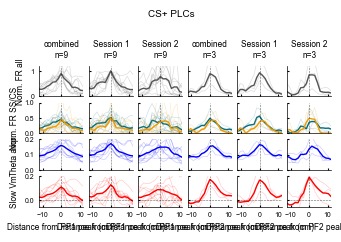

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_CSplus_average_primary_secondary_2sessions.svg
[CS- PLCs] n (PF1): combined=6, S1=6, S2=6
[CS- PLCs] n (PF2): combined=4, S1=4, S2=4


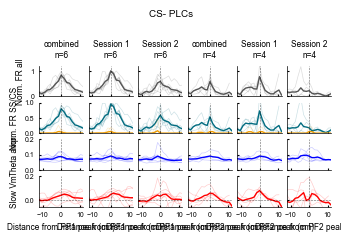

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_CSminus_average_primary_secondary_2sessions.svg


In [46]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    # Shared parameters for both CS+ and CS- 2-session average plots
    pf_avg_fr_row_ylim_max = 1.2
    min_trials_per_column_2sessions = 4  # include only if n_trials >= this threshold in that column
    average_export_dir_2sessions = os.path.join(figure_save_folder, 'pf_distance_centered_2sessions_average_exports')

    common_plot_kwargs = dict(
        smooth_window=smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.4, 1.8),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=pf_avg_fr_row_ylim_max,
        show_plot=True,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        min_trials_per_column=min_trials_per_column_2sessions,
        use_saved_average_exports=True,
        average_export_dir=average_export_dir_2sessions,
        average_export_stage='post',
        enforce_min_traversals_on_saved_exports=False,
        fr_norm_reference_col='session1',
        show_sem_shading=False,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
    )

    plot_specs_2sessions = [
        ('CSplus', 'CS+ PLCs', 'pf_distance_centered_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_distance_centered_CSminus_average_primary_secondary_2sessions.svg'),
    ]

    for category_name, title_text, filename in plot_specs_2sessions:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions(
            dataset=distance_centered_dataset,
            category=category_name,
            title=title_text,
            out_path=out_path,
            **common_plot_kwargs,
        )
        print(f'Generated: {out_path}')


### Statistics

In [47]:
### Stability
stability_min_traversals_per_session = 0
stability_smooth_window_cm = 0.0
stability_auc_window_cm = None
stability_slow_auc_window_cm = (-10.0, 10.0)
stability_min_trials_per_column_2sessions = min_trials_per_column_2sessions
stability_average_export_dir_2sessions = average_export_dir_2sessions
stability_figsize = None  # e.g. (5.0, 6.5)
stability_row_height = 1.2
stability_figsize = (3.2, 2.3)  

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    stability_results = compute_pf_distance_centered_session_stability(
        distance_centered_dataset,
        min_traversals_per_session=stability_min_traversals_per_session,
        smooth_window_cm=stability_smooth_window_cm,
        auc_window_cm=stability_auc_window_cm,
        slow_auc_window_cm=stability_slow_auc_window_cm,
        min_trials_per_column_2sessions=stability_min_trials_per_column_2sessions,
        average_export_dir=stability_average_export_dir_2sessions,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
    )

    print(f"Skipped counts: {stability_results.get('skipped_counts', {})}")

    per_cell_stability = stability_results.get("per_cell_stability", None)
    if per_cell_stability is not None and len(per_cell_stability) > 0:
        print("\nDisplayed cell counts by metric/group:")
        count_cols = {
            "r": "r",
            "peak_shift": "delta_peak_x_cm",
            "auc_ratio": "auc_ratio",
        }
        for metric_name in ["all_spike", "ss", "cs", "theta", "slow"]:
            sub_metric = per_cell_stability[per_cell_stability["metric"] == metric_name].copy()
            if len(sub_metric) == 0:
                continue
            print(f"  {metric_name}:")
            for stat_label, stat_col in count_cols.items():
                if stat_col not in set(sub_metric.columns):
                    continue
                sub_stat = sub_metric.copy()
                if stat_col == "delta_peak_x_cm":
                    sub_stat[stat_col] = sub_stat[stat_col].abs()
                sub_stat = sub_stat[sub_stat[stat_col].notna()]
                # CS row is plotted without CS- PF1 in the current figure.
                if metric_name == "cs":
                    sub_stat = sub_stat[sub_stat["group"].isin(["CSplus_PF1", "CSplus_PF2"])]
                sub_stat["cell_key"] = (
                    sub_stat["animal_id"].astype(str) + "::" + sub_stat["cell_idx"].astype(int).astype(str)
                )
                counts = (
                    sub_stat.groupby("group")["cell_key"]
                    .nunique()
                    .reindex(["CSplus_PF1", "CSplus_PF2", "CSminus_PF1"])
                    .fillna(0)
                    .astype(int)
                )
                print(
                    f"    {stat_label}: "
                    f"CS+ PF1={counts.get('CSplus_PF1', 0)}, "
                    f"CS+ PF2={counts.get('CSplus_PF2', 0)}, "
                    f"CS- PF1={counts.get('CSminus_PF1', 0)}"
                )

    stability_plot_summary = plot_pf_distance_centered_session_stability(
        stability_results,
        figure_save_folder=figure_save_folder,
        figsize=stability_figsize,
        row_height=stability_row_height,
        show_plot=False,
        save_csv=True, 
    )

    print("Stability outputs:")
    print(f"  Per-cell CSV: {stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")


[session_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell2, n_s1=12, n_s2=6, overlap_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_s1=12, n_s2=7, overlap_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_both_sessions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_session1; peak_ratio:zero_or_invalid_peak_session1; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell9, n_s1=12, n_s2=6, overlap_bins=20, auc_bins=20, peak_bins=13, reasons=r:flat_trace_both_sessions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_session1; peak_ratio:zero_or_invalid_peak_session1; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce45_PX_20260118_Cell3, n_s1=15, n_s2=10, overlap_bins=19, auc_bins=19, peak_bins=13, reasons=r:fla

In [48]:
### CS+ PF1/PF2 delta and width
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

delta_width_min_traversals_per_session = 0
delta_width_smooth_window_cm = 0.0
delta_width_min_peak_rate_hz = 1.0
delta_width_min_trials_per_column_2sessions = min_trials_per_column_2sessions
delta_width_average_export_dir_2sessions = average_export_dir_2sessions
delta_width_figsize = (3.8, 2.5)
delta_width_row_height = 2.2

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    delta_width_results = _pcp.compute_csplus_pf_distance_centered_session_delta_width(
        distance_centered_dataset,
        min_traversals_per_session=delta_width_min_traversals_per_session,
        smooth_window_cm=delta_width_smooth_window_cm,
        width_min_peak_rate_hz=delta_width_min_peak_rate_hz,
        min_trials_per_column_2sessions=delta_width_min_trials_per_column_2sessions,
        average_export_dir=delta_width_average_export_dir_2sessions,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
    )

    print(f"Skipped counts: {delta_width_results.get('skipped_counts', {})}")
    print(
        "Cell counts: "
        f"PF1={delta_width_results.get('n_cells_pf1', 0)}, "
        f"PF2={delta_width_results.get('n_cells_pf2', 0)}, "
        f"overlap={delta_width_results.get('n_cells_with_pf1_pf2', 0)}"
    )

    count_summary = delta_width_results.get("count_summary", {})
    if len(count_summary) > 0:
        print("\nDisplayed counts by metric:")
        label_map = {
            "all_spike_delta_fr_s2_s1_over_s1": "all-spike (S2-S1)/S1",
            "all_spike_fwhm_s1_cm": "all-spike width S1",
            "all_spike_fwhm_s2_cm": "all-spike width S2",
            "ss_fwhm_s1_cm": "SS width S1",
            "ss_fwhm_s2_cm": "SS width S2",
            "cs_fwhm_s1_cm": "CS width S1",
            "cs_fwhm_s2_cm": "CS width S2",
        }
        ordered_keys = [
            "all_spike_delta_fr_s2_s1_over_s1",
            "all_spike_fwhm_s1_cm",
            "all_spike_fwhm_s2_cm",
            "ss_fwhm_s1_cm",
            "ss_fwhm_s2_cm",
            "cs_fwhm_s1_cm",
            "cs_fwhm_s2_cm",
        ]
        for category_name, category_label in [("CSplus", "CS+"), ("CSminus", "CS-")]:
            print(f"  {category_label}:")
            for key in ordered_keys:
                counts = count_summary.get(f"{category_name}::{key}", {})
                print(
                    f"    {label_map.get(key, key)}: "
                    f"PF1={counts.get('PF1', 0)}, "
                    f"PF2={counts.get('PF2', 0)}, "
                    f"paired={counts.get('paired', 0)}"
                )

    delta_width_plot_summary = _pcp.plot_csplus_pf_distance_centered_session_delta_width(
        delta_width_results,
        figure_save_folder=figure_save_folder,
        figsize=delta_width_figsize,
        row_height=delta_width_row_height,
        show_plot=False,
        save_csv=True,
    )

    print("Delta-and-width outputs:")
    print(f"  Per-cell CSV: {delta_width_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {delta_width_plot_summary.get('stats_csv')}")
    print(f"  Figure: {delta_width_plot_summary.get('figure_path')}")


Skipped counts: {'missing': 0, 'insufficient_sessions': 0, 'low_traversals': 20}
Cell counts: PF1=15, PF2=7, overlap=7

Displayed counts by metric:
  CS+:
    all-spike (S2-S1)/S1: PF1=3, PF2=3, paired=3
    all-spike width S1: PF1=6, PF2=3, paired=0
    all-spike width S2: PF1=6, PF2=3, paired=0
    SS width S1: PF1=9, PF2=3, paired=0
    SS width S2: PF1=9, PF2=3, paired=0
    CS width S1: PF1=8, PF2=3, paired=0
    CS width S2: PF1=8, PF2=3, paired=0
  CS-:
    all-spike (S2-S1)/S1: PF1=4, PF2=4, paired=4
    all-spike width S1: PF1=5, PF2=2, paired=0
    all-spike width S2: PF1=5, PF2=2, paired=0
    SS width S1: PF1=5, PF2=2, paired=0
    SS width S2: PF1=5, PF2=2, paired=0
    CS width S1: PF1=1, PF2=1, paired=0
    CS width S2: PF1=1, PF2=1, paired=0

PF1/PF2 delta-and-width stats:
All-spike ΔFr: n=3, test=wilcoxon (n<=6), shapiro_p=nan, stat=1, p=0.5, sig=n.s.
All-spike width PF1 S2 vs S1: n=6, test=wilcoxon (n<=6), shapiro_p=nan, stat=4, p=0.219, sig=n.s.
All-spike width PF2 S

In [49]:
# SS/CS PF1/PF2 summary for absolute normalized FR change
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

if 'stability_results' not in locals() or stability_results is None:
    print("stability_results not found. Run the Stability cell first.")
else:
    ss_cs_peak_change_summary = _pcp.plot_pf_distance_centered_abs_norm_fr_change_ss_cs(
        stability_results,
        figure_save_folder=figure_save_folder,
        out_name='pf_distance_centered_abs_norm_fr_change_ss_cs.svg',
        figsize=(0.9, 1.4),
        show_plot=False,
        save_csv=True,
    )
    print('Generated figure:', ss_cs_peak_change_summary.get('figure'))
    print('Stats CSV:', ss_cs_peak_change_summary.get('stats_csv'))
    print('n (SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_ss_pf1_vs_cs_pf1'))
    print('n (SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_ss_pf2_vs_cs_pf2'))
    print('n (SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_ss_pf1_vs_ss_pf2'))
    print('n (CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_cs_pf1_vs_cs_pf2'))
    print('n (ratio SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_cs_pf1'))
    print('n (ratio SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_ratio_ss_pf2_vs_cs_pf2'))
    print('n (ratio SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_ss_pf2'))
    print('n (ratio CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_ratio_cs_pf1_vs_cs_pf2'))


Generated figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_abs_norm_fr_change_ss_cs.svg
Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_abs_norm_fr_change_ss_cs_stats.csv
n (SS PF1 vs CS PF1): 9
n (SS PF2 vs CS PF2): 3
n (SS PF1 vs SS PF2): 3
n (CS PF1 vs CS PF2): 3
n (ratio SS PF1 vs CS PF1): 9
n (ratio SS PF2 vs CS PF2): 3
n (ratio SS PF1 vs SS PF2): 3
n (ratio CS PF1 vs CS PF2): 3


## Compare directions

In [63]:
# Compare directions: heatmaps
direction_avg_mode = "combined"  # combined, S1, or S2
direction_smooth_window = smooth_window  # cm
direction_avg_smooth_window = avg_smooth_window  # cm
direction_max_peak_adjust_cm_pf1 = max_peak_adjust_cm_pf1  # cm
direction_max_peak_adjust_cm_pf2 = max_peak_adjust_cm_pf2  # cm
direction_average_export_subdir = 'pf_distance_centered_2directions_average_exports'


### Heatmaps comparing CW and CCW

In [64]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_2directions = generate_pf_distance_centered_component_heatmaps_2directions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=direction_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.3, 0.3),
        fig_width=2.6,
        trial_height=0.01,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=direction_avg_smooth_window,
        max_peak_adjust_cm_pf1=direction_max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=direction_max_peak_adjust_cm_pf2,
        avg_mode=direction_avg_mode,
        save_average_exports=True,
        average_export_subdir=direction_average_export_subdir,
        print_peak_shift_bins=True,
        show_plot=False,
    )

    for cat, info in distance_heatmap_summary_2directions.items():
        print(f"{cat} folder (2 directions): {info['output_dir']}")
        print(f"{cat} summary (2 directions): {info}")


[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 1: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 4: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 6: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 7: PF1=+1 bins (+1.50 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 1: PF1=-2 bins (-3.00 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce47_PX_20260128 Cell 3: PF1=-3 bins (-4.50 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 4: PF1=+0 bins (+0.00 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce54_PR_20260506 Cell 4: PF1=+0 bins (+0.00 cm), PF2=NA
[CSminus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 1: PF1=-3 bins (-4.50 cm), PF2=NA
  CKII_pAce21_PR_20250806 Cell 4: PF1=-1 bins (-1.50 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce21_PR_20250806 Cell 5: PF1=+0 bins

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:15273: RuntimeWarning: Mean of empty slice
  tr = np.asarray(np.nanmean(sub, axis=0), dtype=float)


CSplus folder (2 directions): /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_centered_2directions_CSplus_heatmaps
CSplus summary (2 directions): {'output_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_centered_2directions_CSplus_heatmaps', 'n_primary_entries': 10, 'n_secondary_entries': 3, 'n_union_entries': 10, 'n_pf2_only_entries': 0, 'n_saved_files': 10, 'n_dual_pf_files': 3, 'mode': 'direction_heatmap_with_avg_mode', 'avg_mode': 'combined', 'average_export_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_2directions_average_exports/CSplus', 'average_export_index_csv': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_2directions_average_exports/C

### Grand Average, comparing directions


PF1 counts: All (n=10), Pref (n=10), Non-pref (n=10)


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:75: RuntimeWarning: Mean of empty slice
  },
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:76: RuntimeWarning: Mean of empty slice
  "ComplexBurstMetrics_AllBursts_CSplus_run": {
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:11773: RuntimeWarning: Mean of empty slice
  trace = np.nanmean(stack, axis=0)


PF2 counts: All (n=3), Pref (n=3), Non-pref (n=3)


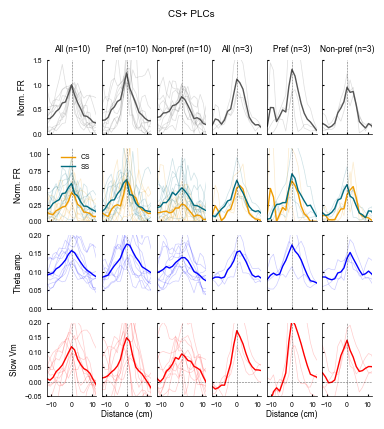

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_CSplus_average_primary_secondary_2directions.svg
PF1 counts: All (n=11), Pref (n=11), Non-pref (n=11)
PF2 counts: All (n=6), Pref (n=6), Non-pref (n=6)


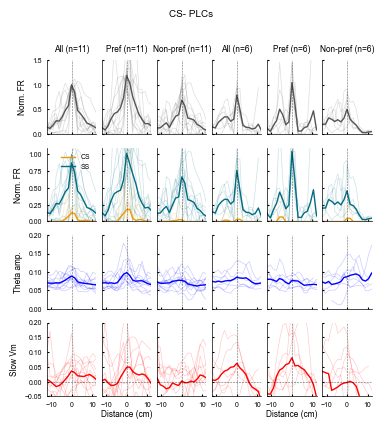

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled_first10min/pf_distance_centered_CSminus_average_primary_secondary_2directions.svg


In [65]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    direction_avg_out_cs_plus = os.path.join(figure_save_folder, 'pf_distance_centered_CSplus_average_primary_secondary_2directions.svg')
    direction_avg_out_cs_minus = os.path.join(figure_save_folder, 'pf_distance_centered_CSminus_average_primary_secondary_2directions.svg')
    direction_average_export_dir = os.path.join(figure_save_folder, direction_average_export_subdir)
    direction_ss_cs_row_ylim_max = 1.1

    direction_common_plot_kwargs = dict(
        smooth_window=direction_smooth_window,
        avg_smooth_window=direction_avg_smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.8, 4.4),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=1.5,
        ss_cs_row_ylim_max=direction_ss_cs_row_ylim_max,
        max_peak_adjust_cm_pf1=direction_max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=direction_max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        use_saved_average_exports=True,
        average_export_dir=direction_average_export_dir,
        average_export_stage='post',
        avg_mode=direction_avg_mode,
        enforce_min_traversals_on_saved_exports=False,
        show_sem_shading=False,
        show_column_counts_in_titles=True,
        show_plot=True,
    )

    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions(
        dataset=distance_centered_dataset,
        category='CSplus',
        title='CS+ PLCs',
        out_path=direction_avg_out_cs_plus,
        **direction_common_plot_kwargs,
    )
    print(f'Generated: {direction_avg_out_cs_plus}')

    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions(
        dataset=distance_centered_dataset,
        category='CSminus',
        title='CS- PLCs',
        out_path=direction_avg_out_cs_minus,
        **direction_common_plot_kwargs,
    )
    print(f'Generated: {direction_avg_out_cs_minus}')



### Statistics, Pref vs Non-pref


In [66]:
### Directionality (Pref vs Non-pref) | Stability-style metrics
# Uses the same metric family as compare-sessions: r, peak shift, AUC ratio, peak ratio, abs normalized change.
directionality_min_traversals_per_type = distance_centered_params.min_traversals_per_type
directionality_smooth_window_cm = 0.0
directionality_auc_window_cm = None
directionality_slow_auc_window_cm = (-10.0, 10.0)
directionality_peak_window_cm = (-10.0, 10.0)
directionality_five_panel_figsize = (2.7, 2.3)
directionality_two_subplot_figsize = (1, 2.3)    # tune 2-subplot figure size
directionality_average_export_dir_2directions = os.path.join(figure_save_folder, direction_average_export_subdir)

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    directionality_results = compute_pf_distance_centered_pref_nonpref_stats(
        distance_centered_dataset,
        min_traversals_per_type=directionality_min_traversals_per_type,
        smooth_window_cm=directionality_smooth_window_cm,
        auc_window_cm=directionality_auc_window_cm,
        slow_auc_window_cm=directionality_slow_auc_window_cm,
        peak_window_cm=directionality_peak_window_cm,
        use_saved_average_exports=True,
        average_export_dir=directionality_average_export_dir_2directions,
        average_export_stage='post',
        avg_mode=direction_avg_mode,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )

    print(f"Skipped counts: {directionality_results.get('skipped_counts', {})}")

    per_cell_directionality = directionality_results.get("per_cell_stability", None)
    if per_cell_directionality is not None and len(per_cell_directionality) > 0:
        print("\nDisplayed cell counts by metric/group:")
        count_cols = {
            "r": "r",
            "peak_shift": "delta_peak_x_cm",
            "auc_ratio": "auc_ratio",
            "peak_ratio": "peak_ratio_s2_s1",
            "abs_norm_change": "peak_abs_sym_diff",
        }
        for metric_name in ["all_spike", "ss", "cs", "theta", "slow"]:
            sub_metric = per_cell_directionality[per_cell_directionality["metric"] == metric_name].copy()
            if len(sub_metric) == 0:
                continue
            print(f"  {metric_name}:")
            for stat_label, stat_col in count_cols.items():
                if stat_col not in set(sub_metric.columns):
                    continue
                sub_stat = sub_metric.copy()
                if stat_col == "delta_peak_x_cm":
                    sub_stat[stat_col] = sub_stat[stat_col].abs()
                sub_stat = sub_stat[sub_stat[stat_col].notna()]
                if metric_name == "cs":
                    sub_stat = sub_stat[sub_stat["group"].isin(["CSplus_PF1", "CSplus_PF2"])]
                sub_stat["cell_key"] = (
                    sub_stat["animal_id"].astype(str) + "::" + sub_stat["cell_idx"].astype(int).astype(str)
                )
                counts = (
                    sub_stat.groupby("group")["cell_key"]
                    .nunique()
                    .reindex(["CSplus_PF1", "CSplus_PF2", "CSminus_PF1"])
                    .fillna(0)
                    .astype(int)
                )
                print(
                    f"    {stat_label}: "
                    f"CS+ PF1={counts.get('CSplus_PF1', 0)}, "
                    f"CS+ PF2={counts.get('CSplus_PF2', 0)}, "
                    f"CS- PF1={counts.get('CSminus_PF1', 0)}"
                )

    directionality_plot_summary = plot_pf_distance_centered_pref_nonpref_stats(
        directionality_results,
        figure_save_folder=figure_save_folder,
        five_panel_figsize=directionality_five_panel_figsize,
        two_subplot_figsize=directionality_two_subplot_figsize,
        show_plot=False,
        save_csv=True,
    )

    print('Directionality outputs:')
    print(f"  Figure (5 columns): {directionality_plot_summary.get('figure')}")
    print(f"  Per-cell CSV: {directionality_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {directionality_plot_summary.get('stats_csv')}")
    print(f"  Figure (2 subplots): {directionality_plot_summary.get('figure_2subplots')}")
    print(f"  Stats CSV (2 subplots): {directionality_plot_summary.get('stats_csv_2subplots')}")





[pref_nonpref_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell2, n_pref=8, n_nonpref=10, overlap_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_nonpreferred; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_pref=8, n_nonpref=11, overlap_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_both_directions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_preferred; peak_ratio:zero_or_invalid_peak_preferred; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell9, n_pref=9, n_nonpref=9, overlap_bins=20, auc_bins=20, peak_bins=13, reasons=r:flat_trace_both_directions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_preferred; peak_ratio:zero_or_invalid_peak_preferred; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce45_PX_20260118_Cell3, n_pref=13, n_nonpref=12, overlap_bins=

# Trial by Trial Analysis, DRZ based (Diretional rate zone)

## Trial by trial plots with DRZ windowing

In [ ]:
import importlib
import utils.placecell_core as _pcc
import utils.placecell_pipeline as _pcp
importlib.reload(_pcc)
importlib.reload(_pcp)

PFDRZParams = _pcp.PFDRZParams
generate_drz_trials_and_dataset = _pcp.generate_drz_trials_and_dataset
generate_pf_drz_component_heatmaps_2sessions = _pcp.generate_pf_drz_component_heatmaps_2sessions
plot_pf_drz_category_primary_secondary_from_dataset_2sessions = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2sessions
compute_pf_drz_session_stability = _pcp.compute_pf_drz_session_stability
plot_pf_drz_session_stability = _pcp.plot_pf_drz_session_stability
plot_pf_drz_abs_norm_fr_change_ss_cs = _pcp.plot_pf_drz_abs_norm_fr_change_ss_cs
generate_pf_drz_component_heatmaps_2directions = _pcp.generate_pf_drz_component_heatmaps_2directions
plot_pf_drz_category_primary_secondary_from_dataset_2directions = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2directions
compute_pf_drz_pref_nonpref_stats = _pcp.compute_pf_drz_pref_nonpref_stats
plot_pf_drz_pref_nonpref_stats = _pcp.plot_pf_drz_pref_nonpref_stats
import os

drz_trial_clip_mode = 'pf_entry_exit'  # 'pf_entry_exit' | 'distance_window'

drz_params = PFDRZParams(
    trial_distance_window_cm=20.0,
    trial_detection_window_cm=6.0,
    trial_clip_mode=drz_trial_clip_mode,
    drz_window=1.0,
    drz_bin=0.1,
    distance_mode='euclidean_to_peak',
    min_traversals=10,
    min_traversals_per_type=5,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    exclude_trials_with_bad_frames=True,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=0.0,
    center_vicinity_min_cm=1,
    center_vicinity_max_cm=5,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    resting_speed_threshold=0.5,
    include_long_cb_as_plateau=True,
    include_resting_plateaus=True,
    cb_plateau_min_duration_ms=150.0,
)

drz_categories = ('CSplus', 'CSminus', 'non-PLC')
drz_plot_figures = True  # False -> build DRZ dataset/summary only, skip traversal SVG generation
drz_trial_plot_dilation_bins = 4  # set 0 for no PF dilation in DRZ trial plots/dataset
drz_trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'
drz_debug_mode = False  # True -> only plot CKII_pAce38_PX_20251126 Cell6 PF1


In [ ]:
## Trial by Trial plots + unified DRZ dataset

drz_result = generate_drz_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    drz_params=drz_params,
    figure_save_folder=figure_save_folder,
    categories=drz_categories,
    plot_figures=drz_plot_figures,
    pf_reliability_dilation_bins=drz_trial_plot_dilation_bins,
    pf_reliability_dilation_shape=drz_trial_plot_dilation_shape,
    debug_mode=drz_debug_mode,
)
drz_dataset = drz_result['dataset']

print('DRZ dataset metadata:')
print(drz_dataset.get('metadata', {}))


In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    print("DRZ trial counts by category and PF rank (per cell):")
    for cat in drz_dataset.get('metadata', {}).get('categories', ()):
        cat_block = drz_dataset.get(cat, {})
        for pf_rank in (1, 2):
            entries = list(cat_block.get(pf_rank, {}).get('entries', []))
            counts = [int(e.get('data', {}).get('all', {}).get('n_trials', 0)) for e in entries]
            print(f'  {cat} PF{pf_rank}: n_cells={len(entries)}, n_trials={counts}')


## Compare Sessions

### Heatmaps comparing two sessions

In [ ]:
drz_two_session_split_mode = 'time_windows'
drz_two_session_split_window_minutes = 5.0
drz_min_trials_per_column_2sessions = 4
drz_average_export_subdir_2sessions = 'pf_drz_2sessions_average_exports'

drz_display_xlim = (-1, 1)
drz_smooth_window = 0.3
drz_avg_smooth_window = 0.0


In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_heatmap_summary_2sessions = generate_pf_drz_component_heatmaps_2sessions(
        dataset=drz_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=drz_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        trial_height=0.025,
        xlim=drz_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=drz_avg_smooth_window,
        avg_ylim_focus_window=(-0.25, 0.25),
        disable_pf2_avg_ylim_sync=True,
        average_export_subdir=drz_average_export_subdir_2sessions,
        split_mode=drz_two_session_split_mode,
        split_window_minutes=drz_two_session_split_window_minutes,
        show_plot=False,
    )
    for cat, info in drz_heatmap_summary_2sessions.items():
        print(f'{cat} summary (2 sessions): {info}')


### Average Plot, comparing two sessions

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_average_export_dir_2sessions = os.path.join(figure_save_folder, drz_average_export_subdir_2sessions)
    for cat, title, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_drz_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_drz_CSminus_average_primary_secondary_2sessions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_drz_category_primary_secondary_from_dataset_2sessions(
            dataset=drz_dataset,
            category=cat,
            title=title,
            out_path=out_path,
            smooth_window=drz_smooth_window,
            avg_smooth_window=drz_avg_smooth_window,
            plot_trials=True,
            trial_alpha=0.2,
            trial_linewidth=0.5,
            theta_ylim=(0, 0.2),
            slow_ylim=(-0.05, 0.2),
            fr_ylim_scale=1.2,
            ss_cs_ylim_scale=1.2,
            figsize_per_block=(3.4, 1.8),
            xlim=drz_display_xlim,
            fr_row_ylim_max=1.2,
            min_traversals_per_type=drz_params.min_traversals_per_type,
            min_trials_per_column=drz_min_trials_per_column_2sessions,
            use_saved_average_exports=True,
            average_export_dir=drz_average_export_dir_2sessions,
            enforce_min_traversals_on_saved_exports=False,
            merge_ss_cs_subplots=True,
            require_both_sessions_for_pf=True,
            fr_norm_reference_col='session1',
            split_mode=drz_two_session_split_mode,
            split_window_minutes=drz_two_session_split_window_minutes,
            show_plot=True,
        )
        print(f'Generated: {out_path}')


### Statistics

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_average_export_dir_2sessions = os.path.join(figure_save_folder, drz_average_export_subdir_2sessions)
    drz_stability_results = compute_pf_drz_session_stability(
        drz_dataset,
        min_traversals_per_session=0,
        smooth_window_cm=0.0,
        auc_window_cm=None,
        slow_auc_window_cm=(-0.5, 0.5),
        min_trials_per_column_2sessions=drz_min_trials_per_column_2sessions,
        average_export_dir=drz_average_export_dir_2sessions,
        split_mode=drz_two_session_split_mode,
        split_window_minutes=drz_two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )
    print(f"Skipped counts: {drz_stability_results.get('skipped_counts', {})}")
    per_cell_stability = drz_stability_results.get('per_cell_stability', None)
    if per_cell_stability is not None:
        print(f'Per-cell stability rows: {len(per_cell_stability)}')
        display(per_cell_stability.head())

    drz_stability_plot_summary = plot_pf_drz_session_stability(
        drz_stability_results,
        figure_save_folder=figure_save_folder,
        figsize=(2.7, 2.3),
        row_height=1.2,
        show_plot=True,
        save_csv=True,
    )
    print('DRZ stability outputs:')
    print(f"  Per-cell CSV: {drz_stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {drz_stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in drz_stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")

    drz_ss_cs_peak_change_summary = plot_pf_drz_abs_norm_fr_change_ss_cs(
        drz_stability_results,
        figure_save_folder=figure_save_folder,
        out_name='pf_drz_abs_norm_fr_change_ss_cs.svg',
        figsize=(0.9, 2.0),
        show_plot=False,
        save_csv=True,
    )
    print('Generated figure:', drz_ss_cs_peak_change_summary.get('figure'))
    print('Stats CSV:', drz_ss_cs_peak_change_summary.get('stats_csv'))
    print('n (SS PF1 vs CS PF1):', drz_ss_cs_peak_change_summary.get('n_ss_pf1_vs_cs_pf1'))
    print('n (SS PF2 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ss_pf2_vs_cs_pf2'))
    print('n (SS PF1 vs SS PF2):', drz_ss_cs_peak_change_summary.get('n_ss_pf1_vs_ss_pf2'))
    print('n (CS PF1 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_cs_pf1_vs_cs_pf2'))
    print('n (ratio SS PF1 vs CS PF1):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_cs_pf1'))
    print('n (ratio SS PF2 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf2_vs_cs_pf2'))
    print('n (ratio SS PF1 vs SS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_ss_pf2'))
    print('n (ratio CS PF1 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_cs_pf1_vs_cs_pf2'))


## Compare directions

In [ ]:
drz_direction_avg_mode = 'S1'
drz_direction_average_export_subdir = 'pf_drz_2directions_average_exports'


### Heatmaps comparing CW and CCW

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_heatmap_summary_2directions = generate_pf_drz_component_heatmaps_2directions(
        dataset=drz_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=drz_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=3,
        trial_height=0.01,
        xlim=drz_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=drz_avg_smooth_window,
        avg_mode=drz_direction_avg_mode,
        average_export_subdir=drz_direction_average_export_subdir,
        show_plot=False,
    )
    for cat, info in drz_heatmap_summary_2directions.items():
        print(f'{cat} summary (2 directions): {info}')


### Grand Average, comparing directions

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_direction_average_export_dir = os.path.join(figure_save_folder, drz_direction_average_export_subdir)
    for cat, title, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_drz_CSplus_average_primary_secondary_2directions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_drz_CSminus_average_primary_secondary_2directions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_drz_category_primary_secondary_from_dataset_2directions(
            dataset=drz_dataset,
            category=cat,
            title=title,
            out_path=out_path,
            smooth_window=drz_smooth_window,
            avg_smooth_window=drz_avg_smooth_window,
            plot_trials=True,
            trial_alpha=0.2,
            trial_linewidth=0.5,
            theta_ylim=(0, 0.2),
            slow_ylim=(-0.05, 0.2),
            fr_ylim_scale=1.2,
            ss_cs_ylim_scale=1.2,
            figsize_per_block=(3.4, 2.4),
            xlim=drz_display_xlim,
            fr_row_ylim_max=1.5,
            ss_cs_row_ylim_max=1.1,
            min_traversals_per_type=drz_params.min_traversals_per_type,
            use_saved_average_exports=True,
            average_export_dir=drz_direction_average_export_dir,
            avg_mode=drz_direction_avg_mode,
            enforce_min_traversals_on_saved_exports=False,
            show_plot=True,
        )
        print(f'Generated: {out_path}')


### Statistics, Pref vs Non-pref

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_direction_average_export_dir = os.path.join(figure_save_folder, drz_direction_average_export_subdir)
    drz_directionality_results = compute_pf_drz_pref_nonpref_stats(
        drz_dataset,
        timepoint_cm=0.0,
        min_traversals_per_type=drz_params.min_traversals_per_type,
        smooth_window_cm=0.0,
        auc_window_cm=None,
        slow_auc_window_cm=(-0.5, 0.5),
        peak_window_cm=(-0.5, 0.5),
        average_export_dir=drz_direction_average_export_dir,
        avg_mode=drz_direction_avg_mode,
    )
    print(f"Skipped counts: {drz_directionality_results.get('skipped_counts', {})}")
    per_cell_directionality = drz_directionality_results.get('per_cell_stability', None)
    if per_cell_directionality is not None:
        print(f'Per-cell directionality rows: {len(per_cell_directionality)}')
        display(per_cell_directionality.head())

    drz_directionality_plot_summary = plot_pf_drz_pref_nonpref_stats(
        drz_directionality_results,
        figure_save_folder=figure_save_folder,
        show_plot=True,
        save_csv=True,
    )
    print('DRZ directionality outputs:')
    for key, value in drz_directionality_plot_summary.items():
        print(f'  {key}: {value}')


# Directionality

In [ ]:
# Directionality (bin-by-bin vector + polar), category-based
directionality_categories = ('CSplus', 'CSminus', 'non-PLC')
directionality_mode = 'head'  # 'head' or 'travel'
directionality_clear_output = True
directionality_first_n_minutes = 10.0  # set to None to use the full session

# Spatial/vector settings
directionality_width_real = 35.5
directionality_height_real = 20.0
directionality_vector_bin_size = 4.0 
directionality_hd_bin_size_deg = 15

# Movement epoch settings
directionality_speed_threshold = float(config.analysis.speed_threshold)
directionality_min_duration_s = float(config.analysis.min_duration_s)
directionality_merge_gap_s = float(config.analysis.merge_gap_s)
directionality_kernel_size = int(config.analysis.kernel_size)

# Bin-level inclusion thresholds
directionality_min_spikes_per_bin = 10
directionality_min_visited_angle_bins = 2
directionality_min_visited_angle_separation_deg = 45.0
directionality_min_occ_frames_per_angle = 100
directionality_hd_count_smooth_sigma = 0.0
directionality_min_pref_vector_strength = 0.0
directionality_preferred_angle_mode = 'peak_cluster_mean'
directionality_pref_angle_std_threshold = 0.0

# Shuffle significance settings
directionality_hd_info_null_mode = 'multinomial'  # 'timeshift' or 'multinomial'; timeshift is moving-only
directionality_hd_time_shift_min_s = 10.0
directionality_hd_time_shift_sessionwise = True

# Display settings
directionality_show_trajectory = True
directionality_use_normalized_rate = False
directionality_max_arrow_length = 'pf_peak'
directionality_max_arrow_std_factor = None
directionality_polar_smooth_sigma = 1.0
directionality_pf_bg_alpha = 0.05
directionality_tuning_curve_color = 'red'
directionality_mini_pref_arrow_length_mode = 'vector_strength'
directionality_mini_pref_arrow_length_min = 0.15
directionality_mini_pref_arrow_length_max = 0.95
directionality_occupancy_style = 'fan'
directionality_tuning_style = 'fan'
directionality_right_panel_width_mode = 'auto'
directionality_figsize_base = (6.5, 5.0)

# Travel-direction parameters (used only when directionality_mode='travel')
directionality_travel_smooth_window = 5
directionality_travel_min_step = 0.0

# Save/export controls
directionality_save_ext = 'svg'
directionality_close_figures = True
directionality_return_data = False



In [ ]:
if spatial_data is None:
    print('spatial_data is None. Run the spatial classification cell first.')
else:
    directionality_batch_summary = generate_bin_by_bin_directionality_plots(
        config=config,
        spatial_data=spatial_data,
        figure_save_folder=figure_save_folder,
        categories=directionality_categories,
        first_n_minutes=directionality_first_n_minutes,
        direction_mode=directionality_mode,
        clear_output=directionality_clear_output,
        width_real=directionality_width_real,
        height_real=directionality_height_real,
        bin_size=directionality_vector_bin_size,
        kernel_size=directionality_kernel_size,
        filter_type='boxcar',
        speed_threshold=directionality_speed_threshold,
        min_duration_s=directionality_min_duration_s,
        merge_gap_s=directionality_merge_gap_s,
        min_spikes_per_bin=directionality_min_spikes_per_bin,
        min_visited_angle_bins=directionality_min_visited_angle_bins,
        min_visited_angle_separation_deg=directionality_min_visited_angle_separation_deg,
        min_occ_frames_per_angle=directionality_min_occ_frames_per_angle,
        hd_count_smooth_sigma=directionality_hd_count_smooth_sigma,
        min_pref_vector_strength=directionality_min_pref_vector_strength,
        preferred_angle_mode=directionality_preferred_angle_mode,
        pref_angle_std_threshold=directionality_pref_angle_std_threshold,
        hd_bin_size_deg=directionality_hd_bin_size_deg,
        travel_smooth_window=directionality_travel_smooth_window,
        travel_min_step=directionality_travel_min_step,
        show_trajectory=directionality_show_trajectory,
        use_normalized_rate=directionality_use_normalized_rate,
        max_arrow_length=directionality_max_arrow_length,
        max_arrow_std_factor=directionality_max_arrow_std_factor,
        polar_smooth_sigma=directionality_polar_smooth_sigma,
        pf_bg_alpha=directionality_pf_bg_alpha,
        tuning_curve_color=directionality_tuning_curve_color,
        mini_pref_arrow_length_mode=directionality_mini_pref_arrow_length_mode,
        mini_pref_arrow_length_min=directionality_mini_pref_arrow_length_min,
        mini_pref_arrow_length_max=directionality_mini_pref_arrow_length_max,
        occupancy_style=directionality_occupancy_style,
        tuning_style=directionality_tuning_style,
        hd_info_null_mode=directionality_hd_info_null_mode,
        hd_time_shift_min_s=directionality_hd_time_shift_min_s,
        hd_time_shift_sessionwise=directionality_hd_time_shift_sessionwise,
        right_panel_width_mode=directionality_right_panel_width_mode,
        figsize_base=directionality_figsize_base,
        save_ext=directionality_save_ext,
        close_figures=directionality_close_figures,
        return_data=directionality_return_data,
    )

    print(f"Directionality root output: {directionality_batch_summary.get('root_output_dir')}")
    print(f"Directionality mode: {directionality_batch_summary.get('direction_mode')}")
    print(f"Directionality null mode: {directionality_batch_summary.get('hd_info_null_mode')}")
    print(f"Directionality time-shift min (s): {directionality_batch_summary.get('hd_time_shift_min_s')}")
    print("Directionality time-shift scope: moving-only within each session")

    cat_summary = directionality_batch_summary.get('categories', {})
    for cat, info in cat_summary.items():
        print(f"\n[{cat}] output: {info.get('output_dir')}")
        print(
            f"  attempted={int(info.get('attempted', 0))}, "
            f"saved={int(info.get('saved', 0))}, "
            f"skipped={int(info.get('skipped', 0))}"
        )
        skip_reasons = info.get('skip_reasons', {}) or {}
        if len(skip_reasons) > 0:
            print(f"  skip_reasons: {skip_reasons}")

        animals = info.get('animals', {}) or {}
        for animal_id in sorted(animals.keys()):
            a = animals[animal_id]
            print(
                f"    {animal_id}: attempted={int(a.get('attempted', 0))}, "
                f"saved={int(a.get('saved', 0))}, skipped={int(a.get('skipped', 0))}"
            )
            if a.get('skip_reasons'):
                print(f"      reasons: {a.get('skip_reasons')}")
            print(f"      folder: {a.get('output_dir')}")



# Egocentric Tuning (Carpenter et al.)

In [ ]:
directionality_categories = ('CSplus', 'CSminus') #,'all-nonPLC')
egocentric_n_jobs = max(1, (os.cpu_count() or 2) - 1)
egocentric_surrogate_chunk_size = 20
egocentric_params = EgocentricTuningParams(
    categories=tuple(directionality_categories),
    first_n_minutes=10.0,
    direction_mode='head',  # 'head' | 'travel'
    time_bin_s=0.1,
    arena_size_cm=(35.5, 20.0),
    local_spatial_bin_cm=5.0, 
    coarse_spatial_bin_cm=2.0, # used for generating SPCUs spatial firing maps 
    n_angle_bins=10,
    speed_min_cm_s=3.0,
    speed_max_cm_s=60.0,
    occupancy_threshold_s=0.2,
    min_occupied_angle_bins=3, 
    min_mean_rate_hz=0.5,
    min_valid_spatial_bins_for_fit=5,
    n_restarts=100,
    optimizer_method='Nelder-Mead',
    n_surrogates=1000,
    n_jobs=egocentric_n_jobs,
    surrogate_chunk_size=egocentric_surrogate_chunk_size,
    random_seed=42,
    clear_output=True,
    save_null_distributions=True,
)

In [ ]:
# Diagnostic plots for valid spatial bins (before RH fitting)
egocentric_diagnostic_summary = generate_egocentric_valid_spatial_bin_diagnostic_plots(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    dpi=180,
    save_formats=("svg",),
)

print(f"Diagnostic folder: {egocentric_diagnostic_summary['diagnostic_root']}")
print('Attempted cells by category:')
for category, n_cells in egocentric_diagnostic_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Analyzed cells by category:')
for category, n_cells in egocentric_diagnostic_summary['analyzed_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Plotted cells by category:')
for category, n_cells in egocentric_diagnostic_summary['plotted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Will-fit cells by category:')
for category, n_cells in egocentric_diagnostic_summary['would_fit_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped cells by category:')
for category, n_cells in egocentric_diagnostic_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_diagnostic_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

diag_manifest_df = egocentric_diagnostic_summary.get('manifest_df')
if diag_manifest_df is None or len(diag_manifest_df) == 0:
    print('No diagnostic plots generated.')
else:
    display(diag_manifest_df.head(20))


In [ ]:
egocentric_summary = run_pooled_egocentric_tuning_analysis(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
)

print(f"Egocentric output folder: {egocentric_summary['figure_root']}")
print(f"Direction mode: {egocentric_summary['direction_mode']}")
print(f"Time bin (s): {egocentric_summary['time_bin_s']}")
print(f"First N minutes: {egocentric_summary['first_n_minutes']}")
print(f"Parallel jobs: {egocentric_summary['n_jobs']}")
print(f"Surrogate chunk size: {egocentric_summary['surrogate_chunk_size']}")
print('Attempted cells by category:')
for category, n_cells in egocentric_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Successful cells by category:')
for category, n_cells in egocentric_summary['successful_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped cells by category:')
for category, n_cells in egocentric_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

egocentric_df = egocentric_summary.get('summary_df')
if egocentric_df is None or len(egocentric_df) == 0:
    print('No successful egocentric fits.')
else:
    display(egocentric_df.head(20))



## Plot results

In [ ]:
# Ensure latest plotting dataclass/function are bound in this kernel
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
EgocentricSummaryPlotParams = _pcp.EgocentricSummaryPlotParams
generate_egocentric_per_cell_summary_plots = _pcp.generate_egocentric_per_cell_summary_plots

# Per-cell trajectory summary figures
plot_spikes_only_in_valid_spatial_bins = False
show_empirical_fit_curve = True
show_spatial_map_with_fitted_arrows = True

# New col5/6 split-map mode (default=True):
# True  -> place-cell-style map pipeline (moving filter + smoothing + occupancy mask)
# False -> legacy egocentric split implementation
split_maps_placecell_style = True

# Place-cell-style split-map settings (used when split_maps_placecell_style=True)
# split_map_bin_size_cm controls col5/6 preferred vs non-preferred maps only.
# Set to None to use cached place-cell bin size; set a float (e.g., 2.5 or 3.0) to override.
split_map_bin_size_cm = None
pc_bin_size_cm = 3.0 # default 1.5cm
pc_smooth_sigma = float(config.place_cell.smooth_sigma)
pc_occ_smooth_sigma = float(config.place_cell.occ_smooth_sigma)
pc_min_occupancy_s = float(config.place_cell.min_occupancy_s)
pc_use_smoothed_occ_mask = False
pc_kernel_size = int(config.analysis.kernel_size)
pc_filter_type = "boxcar"
pc_speed_threshold_cm_s = float(config.analysis.speed_threshold)
pc_min_duration_s = float(config.analysis.min_duration_s)
pc_merge_gap_s = float(config.analysis.merge_gap_s)

plot_params = EgocentricSummaryPlotParams(
    categories=tuple(egocentric_params.categories),
    first_n_minutes=egocentric_params.first_n_minutes,
    direction_mode=egocentric_params.direction_mode,
    time_bin_s=egocentric_params.time_bin_s,
    local_spatial_bin_cm=egocentric_params.local_spatial_bin_cm,
    n_angle_bins=egocentric_params.n_angle_bins,
    occupancy_threshold_s=egocentric_params.occupancy_threshold_s,
    min_occupied_angle_bins=egocentric_params.min_occupied_angle_bins,
    min_mean_rate_hz=egocentric_params.min_mean_rate_hz,
    only_plot_spikes_in_valid_spatial_bins=plot_spikes_only_in_valid_spatial_bins,
    show_empirical_fit_curve=show_empirical_fit_curve,
    show_spatial_map_with_fitted_arrows=show_spatial_map_with_fitted_arrows,
    arena_size_cm=egocentric_params.arena_size_cm,
    speed_min_cm_s=egocentric_params.speed_min_cm_s,
    speed_max_cm_s=egocentric_params.speed_max_cm_s,
    split_maps_placecell_style=split_maps_placecell_style,
    split_map_bin_size_cm=split_map_bin_size_cm,
    pc_bin_size_cm=pc_bin_size_cm,
    pc_smooth_sigma=pc_smooth_sigma,
    pc_occ_smooth_sigma=pc_occ_smooth_sigma,
    pc_min_occupancy_s=pc_min_occupancy_s,
    pc_use_smoothed_occ_mask=pc_use_smoothed_occ_mask,
    pc_kernel_size=pc_kernel_size,
    pc_filter_type=pc_filter_type,
    pc_speed_threshold_cm_s=pc_speed_threshold_cm_s,
    pc_min_duration_s=pc_min_duration_s,
    pc_merge_gap_s=pc_merge_gap_s,
    clear_output=True,
    save_formats=("svg",),
    summary_df=egocentric_df,
)

egocentric_plot_summary = generate_egocentric_per_cell_summary_plots(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
    plot_params=plot_params,
)

print(f"Per-cell summary folder: {egocentric_plot_summary['per_cell_root']}")
print('Analyzed cells by category:')
for category, n_cells in egocentric_plot_summary['analyzed_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Two-panel cells by category:')
for category, n_cells in egocentric_plot_summary['two_panel_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('One-panel cells by category:')
for category, n_cells in egocentric_plot_summary['one_panel_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped plot cells by category:')
for category, n_cells in egocentric_plot_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_plot_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

plot_skip_df = egocentric_plot_summary.get('skip_df')
if plot_skip_df is not None and len(plot_skip_df) > 0:
    print('Plot skip reasons:')
    print(plot_skip_df['reason'].value_counts())

plot_manifest_df = egocentric_plot_summary.get('manifest_df')
if plot_manifest_df is None or len(plot_manifest_df) == 0:
    print('No per-cell summary plots generated.')
else:
    display(plot_manifest_df.head(20))


In [ ]:
# Egocentric summary statistics (CS+ vs CS- PLCs)
import importlib
import numpy as np
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
summarize_egocentric_csplus_csminus_stats = _pcp.summarize_egocentric_csplus_csminus_stats

# Style/size controls (match pooled style; tune as needed)
stats_fig_pass_size = (3.0, 2.0)
stats_fig_mrl_size = (2.8, 2.0)
stats_font_family = 'Arial'
stats_font_size = 6.0
stats_axes_labelsize = 6.0
stats_axes_titlesize = 6.0
stats_tick_labelsize = 5.0
stats_legend_fontsize = 5.0
stats_axes_linewidth = 0.5
stats_remove_top_right_spines = True
stats_csplus_color = '#EE9B00'
stats_csminus_color = '#026C80'

egocentric_stats = summarize_egocentric_csplus_csminus_stats(
    egocentric_summary,
    categories=('CSplus', 'CSminus'),
    make_plots=True,
    random_seed=42,
    save_formats=('svg',),
    fig_pass_size=stats_fig_pass_size,
    fig_mrl_size=stats_fig_mrl_size,
    font_family=stats_font_family,
    font_size=stats_font_size,
    axes_labelsize=stats_axes_labelsize,
    axes_titlesize=stats_axes_titlesize,
    tick_labelsize=stats_tick_labelsize,
    legend_fontsize=stats_legend_fontsize,
    axes_linewidth=stats_axes_linewidth,
    remove_top_right_spines=stats_remove_top_right_spines,
    category_colors={'CSplus': stats_csplus_color, 'CSminus': stats_csminus_color},
)

if not bool(egocentric_stats.get('ok', False)):
    print(f"Summary stats unavailable: {egocentric_stats.get('reason', 'unknown')}")
else:
    display(egocentric_stats['pass_counts'])
    mrl_stats_df = egocentric_stats.get('mrl_stats', None)
    if mrl_stats_df is not None and len(mrl_stats_df) > 0:
        display(mrl_stats_df)
    u = egocentric_stats.get('mannwhitney_u', np.nan)
    p = egocentric_stats.get('mannwhitney_p', np.nan)
    if np.isfinite(u) and np.isfinite(p):
        print(f"Mann-Whitney U: U={u:.3f}, p={p:.4g}")

if egocentric_stats.get('saved_files'):
    print('Saved files:')
    for key, val in egocentric_stats['saved_files'].items():
        print(f'  {key}: {val}')



# GLM

In [ ]:
glm_session_mode = "session1"  # "session1" | "combined_s1_s2"
glm_direction_predictor = "head"  # "head" | "travel" | "both"
glm_temporal_smooth_bins = 3.0  # set to 0 to disable temporal smoothing
glm_require_full_valid_bin = True  # keep only full-duration bins with no invalid frames
glm_use_regularization = True  # ridge-style regularization when reg_l1_wt = 0
glm_reg_alpha = 0.1  # ridge strength; larger values shrink coefficients more
glm_reg_l1_wt = 0.0  # 0 = pure ridge, 1 = lasso
glm_rbf_sigma_cm = 6.0  # spatial smoothness of the position basis
glm_predicted_map_min_occupancy_bins = 0.0  # hide predicted-map bins visited fewer times than this

glm_params = GLMParams(
    categories=("CSplus", "CSminus"),
    response_kinds=("all_spike", "simple_spike", "complex_spike"),
    time_bin_s=0.3,
    temporal_smooth_bins=glm_temporal_smooth_bins,
    require_full_valid_bin=glm_require_full_valid_bin,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    direction_predictor=glm_direction_predictor,
    session_mode=glm_session_mode,
    min_total_spikes=20,
    standardize=True,
    include_accel=False,
    include_session_covariate=False,
    use_regularization=glm_use_regularization,
    reg_alpha=glm_reg_alpha,
    reg_l1_wt=glm_reg_l1_wt,
    rbf_sigma_cm=glm_rbf_sigma_cm,
    predicted_map_min_occupancy_bins=glm_predicted_map_min_occupancy_bins,
)

glm_summary = run_pooled_placecell_glm_analysis(
    config=config,
    spatial_data=spatial_data,
    glm_params=glm_params,
    figure_save_folder=figure_save_folder,
)

print(f"GLM output folder: {glm_summary['figure_root']}")
print(f"Session mode: {glm_summary['session_mode']}")
print(f"Direction predictor: {glm_summary['direction_predictor']}")
print(f"Temporal smoothing (bins): {glm_temporal_smooth_bins}")
print(f"Require full valid bin: {glm_require_full_valid_bin}")
print(f"Use regularization: {glm_summary['use_regularization']}")
print(f"Ridge alpha: {glm_summary['reg_alpha']}")
print(f"RBF sigma (cm): {glm_summary['rbf_sigma_cm']}")
print(f"Predicted-map min occupancy bins: {glm_summary['predicted_map_min_occupancy_bins']}")

print("Attempted cells by category:")
for category, n_cells in glm_summary["attempted_cells_by_category"].items():
    print(f"  {category}: {n_cells}")

print("Successful models by category/response:")
for category, counts in glm_summary["successful_models_by_category_response"].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Skipped models by category/response:")
for category, counts in glm_summary["skipped_models_by_category_response"].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Saved files:")
for key, out_path in glm_summary["saved_files"].items():
    print(f"  {key}: {out_path}")

for category in ("CSplus", "CSminus"):
    cat_df = glm_summary["group_summary_by_category"].get(category)
    print(f"\n{category} group summary:")
    if cat_df is None or len(cat_df) == 0:
        print("  No fitted models.")
    else:
        display(cat_df.head(20))


# LN model

In [ ]:
# Hardcastle-style LN model (P/H/S only; theta omitted for this dataset)
ln_session_mode = "session1"  # "session1" | "combined_s1_s2"
ln_direction_predictor = "head"  # "head" | "travel"
ln_time_bin_s = 0.4
ln_moving_only = False
ln_require_full_valid_bin = True
ln_position_n_bins = (18, 10)
ln_min_position_bin_occupancy_s = ln_time_bin_s   # only keep LN time bins whose position bin was occupied for at least this long
ln_n_direction_bins = 12
ln_n_speed_bins = 10
ln_max_speed_cm_s = 30.0
ln_roughness_position = 8.0
ln_roughness_direction = 50.0
ln_roughness_speed = 50.0
ln_cv_num_folds = 10
ln_cv_section_repeats = 3
ln_selection_alpha = 0.05
ln_baseline_alpha = 0.2  # relax this to reduce the "None" group
ln_smoothing_sigma_bins = 1.0 #1D Gaussian kernel over time bins.
ln_smoothing_radius_bins = 3 # half-width of the temporal Gaussian kernel.
ln_position_smooth_sigma = 1 #2D spatial Gaussian smoothing sigma applied only to the empirical position tuning map.
ln_min_total_spikes = 20
ln_optimizer_maxiter = 400
ln_travel_smooth_window = 5
ln_travel_min_step = 0.0

ln_params = LNModelParams(
    categories=("CSplus", "CSminus"),
    response_kinds=("all_spike", "simple_spike", "complex_spike"),
    session_mode=ln_session_mode,
    time_bin_s=ln_time_bin_s,
    moving_only=ln_moving_only,
    require_full_valid_bin=ln_require_full_valid_bin,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    direction_predictor=ln_direction_predictor,
    min_total_spikes=ln_min_total_spikes,
    position_n_bins=ln_position_n_bins,
    min_position_bin_occupancy_s=ln_min_position_bin_occupancy_s,
    n_direction_bins=ln_n_direction_bins,
    n_speed_bins=ln_n_speed_bins,
    max_speed_cm_s=ln_max_speed_cm_s,
    roughness_position=ln_roughness_position,
    roughness_direction=ln_roughness_direction,
    roughness_speed=ln_roughness_speed,
    cv_num_folds=ln_cv_num_folds,
    cv_section_repeats=ln_cv_section_repeats,
    selection_alpha=ln_selection_alpha,
    baseline_alpha=ln_baseline_alpha,
    smoothing_sigma_bins=ln_smoothing_sigma_bins,
    smoothing_radius_bins=ln_smoothing_radius_bins,
    position_smooth_sigma=ln_position_smooth_sigma,
    travel_smooth_window=ln_travel_smooth_window,
    travel_min_step=ln_travel_min_step,
    optimizer_maxiter=ln_optimizer_maxiter,
)


In [ ]:
ln_summary = run_pooled_placecell_ln_model_analysis(
    config=config,
    spatial_data=spatial_data,
    ln_params=ln_params,
    figure_save_folder=figure_save_folder,
)

print(f"LN output folder: {ln_summary['figure_root']}")
print(f"Session mode: {ln_summary['session_mode']}")
print(f"Direction predictor: {ln_summary['direction_predictor']}")
print(f"Time bin (s): {ln_time_bin_s}")
print(f"Moving only: {ln_moving_only}")
print(f"Require full valid bin: {ln_require_full_valid_bin}")
print(f"CV folds: {ln_cv_num_folds}")
print(f"CV section repeats: {ln_cv_section_repeats}")
print(f"Min position-bin occupancy (s): {ln_summary['min_position_bin_occupancy_s']}")
print(f"Forward alpha: {ln_summary['forward_alpha']}")
print(f"Baseline alpha: {ln_summary['baseline_alpha']}")

print("Attempted cells by category:")
for category, n_cells in ln_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")

print("Successful models by category/response:")
for category, counts in ln_summary['successful_models_by_category_response'].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Skipped models by category/response:")
for category, counts in ln_summary['skipped_models_by_category_response'].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Saved files:")
for key, out_path in ln_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

for category in ("CSplus", "CSminus"):
    cat_df = ln_summary['summary_by_category'].get(category)
    print(f"\n{category} LN summary:")
    if cat_df is None or len(cat_df) == 0:
        print("  No fitted models.")
    else:
        display(cat_df.head(20))
